นายปุลวัชร ลี้เจริญ 62070256

# Assignment 2 - Individual Assignment

In [ ]:
# สำหรับ Google Colab: clone repo ก่อนเพื่อให้เข้าถึง data/# !git clone https://github.com/PlaiPunlawat/kmitl-news-scraping-text-classification.git# %cd kmitl-news-scraping-text-classification

## Task 1: Text Scraping

In [ ]:
# library ที่ใช้ในการ scraping ข้อมูล
import requests
import bs4
import pandas as pd
import numpy as np

In [ ]:
# root URL ที่เราจะใช้ scraping ข้อมูล
root_URL = 'http://www.it.kmitl.ac.th/~teerapong/news_archive/index.html'

### 1: Function ที่ใช้ในการ Scraping

In [ ]:
# function สำหรับ get html ของหน้า website จาก URL
def get_html(link):
  response = requests.get(link)
  html_page = bs4.BeautifulSoup(response.content, 'lxml')
  return html_page

In [ ]:
# function สำหรับ get path ที่อยู่ใน href ของหน้า website
def get_all_link(html_page):
  link = []
  for a in html_page.find_all('a'):
    if a['href'] != '#' and a['href'] != 'index.html':
      link.append(root_URL.replace('index.html', a['href']))
  return link

In [ ]:
# function สำหรับ get catagory ที่อยู่ในหน้า website
def get_category(html_page):
  category = []
  for i in html_page:
      tags = i.select('td.category')
      for tag in tags:
        if tag.text[1:] != 'N/A':
          category.append(tag.text[1:])
  return category

In [ ]:
# function สำหรับ get heading ที่อยู่ในหน้า website
def get_heading(html_page):
  heading = []
  for i in html_page:
    tags = i.select('td > a')
    for tag in tags:
      heading.append(tag.text)
  return heading

In [ ]:
# function สำหรับ get content ทั้งหมดที่อยู่ใน website
def get_content(link, heading):
  all_content = []
  for i in range(1408):
    content = ""
    tags = link[i].select('div.main > p')
    for tag in tags:
      if tag.text != heading[i] and tag.text != heading[i].replace('Featured: ', '') and tag.text != "":
        content += tag.text + " "
    content = content.replace(' Return to article search results', '')
    content = content.replace(' Comments are closed for this article.', '')
    all_content.append(content)
  return all_content

function ที่ใช้เรียกรวม function ทั้งหมด

In [ ]:
# function สำหรับ get article ทังหมดที่อยู่ใน website
def get_article_info(Web_URL):

  all_link = get_all_link(get_html(Web_URL))

  all_html_page = []
  for i in all_link:
    html_page = get_html(i)
    all_html_page.append(html_page)

  Category = get_category(all_html_page)

  Heading = get_heading(all_html_page)

  Link = []
  for i in all_html_page:
    Link += get_all_link(i)

  Content_Page = []
  for i in Link:
    Content_Page.append(get_html(i))

  Content = get_content(Content_Page, Heading)

  return Category, Heading, Link, Content

### 2: Scraping ข้อมูล และแสดงผลข้อมูลให้อยู่ในรูปแบบ Data frame

In [ ]:
# ทำการเรียก function ที่สร้างเองไว้ และรับค่าที่ออกมาจาก function
Category, Heading, Link, Content = get_article_info(root_URL)

In [ ]:
# นำข้อมูลที่ได้จาก function ก่อนหน้ามาสร้าง dataframe
save_df = pd.DataFrame(list(zip(Category, Heading, Link, Content)), columns =['Article_Category', 'Article_Heading', 'Article_Link',  'Article_Content'])

# ทำการรวมข้อมูล heading และ content เข้าด้วยกัน
save_df['Article_Heading + Article_Content'] = save_df['Article_Heading'] + " " + save_df['Article_Content']
save_df

,Article_Category,Article_Heading,Article_Link,Article_Content,Article_Heading + Article_Content
0,technology,21st-Century Sports: How Digital Technology Is...,http://www.it.kmitl.ac.th/~teerapong/news_arch...,The sporting industry has come a long way sinc...,21st-Century Sports: How Digital Technology Is...
1,business,Asian quake hits European shares,http://www.it.kmitl.ac.th/~teerapong/news_arch...,Shares in Europe's leading reinsurers and trav...,Asian quake hits European shares Shares in Eur...
2,technology,BT offers free net phone calls,http://www.it.kmitl.ac.th/~teerapong/news_arch...,BT is offering customers free internet telepho...,BT offers free net phone calls BT is offering ...
3,business,Barclays shares up on merger talk,http://www.it.kmitl.ac.th/~teerapong/news_arch...,Shares in UK banking group Barclays have risen...,Barclays shares up on merger talk Shares in UK...
4,sport,Barkley fit for match in Ireland,http://www.it.kmitl.ac.th/~teerapong/news_arch...,England centre Olly Barkley has been passed fi...,Barkley fit for match in Ireland England centr...
...,...,...,...,...,...
1403,sport,Woodward eyes Brennan for Lions,http://www.it.kmitl.ac.th/~teerapong/news_arch...,Toulouse's former Irish international Trevor B...,Woodward eyes Brennan for Lions Toulouse's for...
1404,business,WorldCom trial starts in New York,http://www.it.kmitl.ac.th/~teerapong/news_arch...,"The trial of Bernie Ebbers, former chief execu...",WorldCom trial starts in New York The trial of...
1405,business,Yukos accused of lying to court,http://www.it.kmitl.ac.th/~teerapong/news_arch...,Russian oil firm Yukos lied to a US court in a...,Yukos accused of lying to court Russian oil fi...
1406,business,Yukos drops banks from court bid,http://www.it.kmitl.ac.th/~teerapong/news_arch...,Russian oil company Yukos has dropped the thre...,Yukos drops banks from court bid Russian oil c...


In [ ]:
# ทำการแยก path ออกจาก link ที่เคยรวมเข้าไปเพื่อเอามาใช้เป็นชื่อสำหรับ save file
name = []
for i in save_df['Article_Link']:
  name.append(str(i).replace('http://www.it.kmitl.ac.th/~teerapong/news_archive/', '')[:-5])

### 3: ทำการ Save ข้อมูลที่ได้จากการ scraping ข้อมูล

In [ ]:
# หมายเหตุ: รันส่วนนี้เฉพาะตอน re-scraping เท่านั้น (เว็บไซต์ต้นทางอาจออฟไลน์แล้ว)# สำหรับการใช้งานทั่วไปในโปรเจกต์นี้ให้ใช้ snapshot ในโฟลเดอร์ data/for i in range(len(save_df)):  # เอา path ที่ได้จากขั้นตอนก่อนหน้ามาใช้เป็นชื่อ file สำหรับ save ข้อมูลที่ต้อง save แบบแยกไฟล์  content_name = str(i)+ name[i].replace(' ', '_') + '.txt'  heading_name = str(i)+ name[i].replace(' ', '_') + '.txt'  heading_plus_content_name = str(i) + name[i].replace(' ', '_') + '.txt'  # ทำการ save content แบบแยก file  np.savetxt(r'data/datastore/content/' +  content_name, [save_df['Article_Content'][i]], fmt='%s')  # ทำการ save heading แบบแยก file  np.savetxt(r'data/datastore/heading/' +  heading_name, [save_df['Article_Heading'][i]], fmt='%s')  # ทำการรวม heading และ content เข้าด้วยกัน และ save แบบแยก file  np.savetxt(r'data/datastore/heading_plus_content/' +  heading_plus_content_name, [save_df['Article_Heading + Article_Content'][i]], fmt='%s')# ทำการรวม content จากแต่ละหัวข้อและ save รวมเป็น file เดียวnp.savetxt(r'data/articles_content.txt', save_df['Article_Content'].values, fmt='%s')# ทำการรวม heading และ content จากแต่ละหัวข้อเข้าด้วยกันและ save เรวมเป็น file เดียวnp.savetxt(r'data/articles_heading_content.txt', save_df['Article_Heading + Article_Content'].values, fmt='%s')# ทำการรวม catagory  จากแต่ละหัวข้อเข้าด้วยกันและ save รวมกันเป็น file เดียวnp.savetxt(r'data/categories.txt', save_df['Article_Category'].values, fmt='%s')

## Task 2: เตรียมข้อมูล

### 1: โหลดข้อมูล snapshot จากโฟลเดอร์ data/ มาสร้างเป็น Data frame

In [ ]:
# ทำการอ่านไฟล์ category จาก snapshot ในโฟลเดอร์ data/df1 = pd.read_fwf('data/categories.txt', header = None, names = ['Article_Category'])# ทำการอ่านไฟล์ content จาก snapshot ในโฟลเดอร์ data/df2 = pd.read_fwf('data/articles_content.txt', header = None, names = ['Article_Content'], index_col=False)# ทำการอ่านไฟล์ heading + content จาก snapshot ในโฟลเดอร์ data/df3 = pd.read_fwf('data/articles_heading_content.txt', header = None, names = ['Article_Heading + Article_Content'], index_col=False)

In [ ]:
# นำ file ที่อ่านได้จากขั้นตอนก่อนหน้ามาสร้างเป็น data frame เพื่อใช้สำหรับทำ text classification
df = pd.concat([df1, df2, df3], axis=1)
df

,Article_Category,Article_Content,Article_Heading + Article_Content
0,technology,The sporting industry has come a long way sinc...,21st-Century Sports: How Digital Technology Is...
1,business,Shares in Europe's leading reinsurers and trav...,Asian quake hits European shares Shares in Eur...
2,technology,BT is offering customers free internet telepho...,BT offers free net phone calls BT is offering ...
3,business,Shares in UK banking group Barclays have risen...,Barclays shares up on merger talk Shares in UK...
4,sport,England centre Olly Barkley has been passed fi...,Barkley fit for match in Ireland England centr...
...,...,...,...
1403,sport,Toulouse's former Irish international Trevor B...,Woodward eyes Brennan for Lions Toulouse's for...
1404,business,"The trial of Bernie Ebbers, former chief execu...",WorldCom trial starts in New York The trial of...
1405,business,Russian oil firm Yukos lied to a US court in a...,Yukos accused of lying to court Russian oil fi...
1406,business,Russian oil company Yukos has dropped the thre...,Yukos drops banks from court bid Russian oil c...


### 2: ทำ Label Encoder

In [ ]:
# นำเอาข้อมูล catagory มาแปลงเป็นตัวเลขใช้ทำ text classification
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(df['Article_Category'].unique())
df['Article_Num_Category'] = le.transform(df['Article_Category'])

In [ ]:
# ทำการ drop บทความที่มี Heading และ Content ซ้ำกันออกจาก data frame
main_df = df.drop_duplicates(subset=['Article_Heading + Article_Content'], keep="first")
main_df

,Article_Category,Article_Content,Article_Heading + Article_Content,Article_Num_Category
0,technology,The sporting industry has come a long way sinc...,21st-Century Sports: How Digital Technology Is...,2
1,business,Shares in Europe's leading reinsurers and trav...,Asian quake hits European shares Shares in Eur...,0
2,technology,BT is offering customers free internet telepho...,BT offers free net phone calls BT is offering ...,2
3,business,Shares in UK banking group Barclays have risen...,Barclays shares up on merger talk Shares in UK...,0
4,sport,England centre Olly Barkley has been passed fi...,Barkley fit for match in Ireland England centr...,1
...,...,...,...,...
1403,sport,Toulouse's former Irish international Trevor B...,Woodward eyes Brennan for Lions Toulouse's for...,1
1404,business,"The trial of Bernie Ebbers, former chief execu...",WorldCom trial starts in New York The trial of...,0
1405,business,Russian oil firm Yukos lied to a US court in a...,Yukos accused of lying to court Russian oil fi...,0
1406,business,Russian oil company Yukos has dropped the thre...,Yukos drops banks from court bid Russian oil c...,0


### 3: ทำการ Split ข้อมูล

In [ ]:
# ทำการ split ข้อมูลที่ scrap มาเพื่อใช้สำหรับ train และ test
from sklearn.model_selection import train_test_split
X = main_df['Article_Content']
Y = main_df['Article_Num_Category']
# แบ่งข้อมูล 80% สำหรับ train และ 20% สำหรับ test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.2, random_state=42)

## Task 3: Text Pre-Processing

### 1: Text Tokenization

นำเอาบทความที่ได้มาตัดแบ่งออกเป็นคำๆ

In [ ]:
# ใช้ CountVectorizer สำหรับทำ text tokenization
from sklearn.feature_extraction.text import CountVectorizer

standard_tokenizer = CountVectorizer().build_tokenizer()

### 2: Text normalization

นำเอาคำหลายๆ คำที่ได้จากขึ้นตอนก่อนหน้ามาทำการ normalize เพื่อตัดคำให้เหลือเฉพาะคำที่สำคัญต่อการทำ text classification

In [ ]:
# ทำ text normalization ด้วย stemmer และ lemmatizer# stemmer แต่ละประเภทที่ใช้from nltk.stem import PorterStemmerfrom nltk.stem import SnowballStemmerfrom nltk.stem import LancasterStemmer# lemmatizerimport nltknltk.download('wordnet')nltk.download('omw-1.4')nltk.download('averaged_perceptron_tagger')nltk.download('averaged_perceptron_tagger_eng')  # NLTK >= 3.9

เครื่องมือในการทำ Text normalization มีอยู่ 2 ประเภทคือ

1.   Stemmer
2.   Lemmatizer

โดยชนิดของ Stemmer และ Lemmatizer ที่นำมาใช้ได้แก่


**Porter Stemmer**

In [ ]:
# function ที่ใช้ Porter Stemmer normalize text
def PorterStemmer_tokenizer(text):
    # tokenize text
    tokens = standard_tokenizer(text)
    # ทำการ normalize text ที่ถูก tokenize ด้วย Porter Stemmer
    stemmer = PorterStemmer()
    stems = []
    for token in tokens:
        stems.append( stemmer.stem(token.lower()) )
    return stems

**Snowball Stemmer**

In [ ]:
# function ที่ใช้ Snowball Stemmer normalize text
def SnowballStemmer_tokenizer(text):
    # tokenize text
    tokens = standard_tokenizer(text)
    # ทำการ normalize text ที่ถูก tokenize ด้วย Snowball Stemmer
    stemmer = SnowballStemmer(language='english')
    stems = []
    for token in tokens:
        stems.append( stemmer.stem(token.lower()) )
    return stems

**Lancaster Stemmer**

In [ ]:
# function ที่ใช้ Lancaster Stemmer normalize text
def LancasterStemmer_tokenizer(text):
    # tokenize text
    tokens = standard_tokenizer(text)
    # ทำการ normalize text ที่ถูก tokenize ด้วย Lancaster Stemmer
    stemmer = LancasterStemmer()
    stems = []
    for token in tokens:
        stems.append( stemmer.stem(token.lower()) )
    return stems

**Lemmatizer with POS**

In [ ]:
# function ที่ใช้ Lemmatizer with POS normalize text
def Lemma_w_POS_Tag_tokenizer(text):
    # สร้าง nested function แปลง POS tag สำหรับ Lemmatizer
    def convert_tags(tag):
        if tag == 'vbd' or tag == 'vbg' or tag == 'vbz':
            return 'v'
        else:
            return 'n'

    # tokenize text
    tokens = standard_tokenizer(text)
    tokens_with_pos_tag = nltk.pos_tag(tokens)

    # ทำการ normalize text ที่ถูก tokenize ด้วย Lemmatizer
    lemmatizer = nltk.WordNetLemmatizer()
    lemma_tokens = []
    for token in tokens_with_pos_tag:
        new_tag = convert_tags(token[1].lower())
        lemma_tokens.append(lemmatizer.lemmatize(token[0], new_tag))

    return lemma_tokens

### 3: Term Weighting & Vectorizer

นำ text ที่ได้จากขั้นตอนก่อนหน้ามาทำ Term Weighting เพื่อเพิ่มนำหนักให้กับ text ที่สำคัญๆ ไว้ใช้ในการทำ Text Classification และทำ Vectorizer เพื่อแปลงข้อมูลให้อยู่ในรูปแบบ vector เพื่อให้ Model สามารถนำไปใช้งานได้

In [ ]:
# ใช้ TfidfVectorizer สำหรับทำ term weighting และ vectorizer เนื่องจากใน TfidfVectorizer มีค่ำสั่งสำหรับทำ term weighting ด้วยไม่เหมือน CountVectorizer ที่ทำการนับจำนวนเพียงอย่างเดียวfrom sklearn.feature_extraction.text import TfidfVectorizer

### 4: Pre-Processing

Function ที่ใช้ในการ pre-process text ตามที่กล่าวไปก่อนหน้า

In [ ]:
# function สำหรับทำ text pre-processing
def pre_process(tokeniz, X_train, X_test):
  # function สำหรับทำ vectorizer ด้วย Tfidf
  tfidf_vectorizer = TfidfVectorizer(
      # นำ function normalize ก่อนหน้ามาใส่ใน parameter: tokenizer
      tokenizer = tokeniz,
      # ตั้ง stop_words เป็น ภาษาอังกฤษ เพื่อใช้ในการตัดคำ
      stop_words = "english",
      # ตั้ง min_df = 3 หากคำไหนน้อยกว่า 3 ตัวจะทำการตัดคำนั้นทิ้ง
      min_df = 3,
      # ตั้งให้มีการทำ ngram_rang = (1, 2)
      ngram_range = (1,2))

  # ให้ TfidfVectorizer ที่สร้างมา fit ข้อมูล

  # ให้ TfidfVectorizer ที่ผ่านการ fit แล้วมา transform ข้อมูล X_train, X_test
  return tfidf_vectorizer.fit(X_train), tfidf_vectorizer.transform(X_train), tfidf_vectorizer.transform(X_test)

แบ่งการทำ Text Pre-Processing ตามเครื่องมือในการทำ Text Normalization เพื่อดูว่าเครื่องมือไหนทำให้ได้ score ในการทำ text classification กับข้อมูลชุดนี้มากกว่ากัน

**1: Porter Stemmer**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Porter Stemmer
tfidf_vectorizer_PorterStemmer, X_train_PorterStemmer, X_test_PorterStemmer = pre_process(PorterStemmer_tokenizer, X_train, X_test)

NameError: name 'X_train' is not defined

**2: Snowball Stemmer**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Snowball Stemmer
tfidf_vectorizer_SnowballStemmer, X_train_SnowballStemmer, X_test_SnowballStemmer = pre_process(SnowballStemmer_tokenizer, X_train, X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor',

**3: Lancaster Stemmer**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Lancaster Stemmer
tfidf_vectorizer_LancasterStemmer, X_train_LancasterStemmer, X_test_LancasterStemmer = pre_process(LancasterStemmer_tokenizer, X_train, X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'aft', 'afterward', 'al', 'alon', 'alway', 'anoth', 'anyon', 'anyth', 'anywh', 'ar', 'becam', 'becaus', 'becom', 'bef', 'besid', 'bil', 'cal', 'describ', 'don', 'dur', 'eith', 'elev', 'els', 'elsewh', 'ev', 'everyon', 'everyth', 'everywh', 'exceiv', 'fil', 'fir', 'fiv', 'form', 'ful', 'furth', 'giv', 'hav', 'hent', 'hereaft', 'howev', 'hundr', 'indee', 'int', 'lat', 'mad', 'meanwhil', 'mil', 'min', 'mor', 'moreov', 'mov', 'nam', 'neith', 'nev', 'nin', 'non', 'noon', 'noth', 'nowh', 'oft', 'ont', 'oth', 'otherw', 'ourselv', 'ov', 'perhap', 'pleas', 'rath'

**4: Lemmatizer with POS**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Lemmatizer with POS
tfidf_vectorizer_Lemma_w_POS_Tag, X_train_Lemma_w_POS_Tag, X_test_Lemma_w_POS_Tag = pre_process(Lemma_w_POS_Tag_tokenizer, X_train, X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['le', 'u'] not in stop_words.
  'stop_words.' % sorted(inconsistent))


### 5: Document-Term Matrix

In [ ]:
# function สำหรับสร้าง Document-Term Matrix
def doc_term_matrix(data, vectorizer):
  td = pd.DataFrame(data.todense())
  td.columns = vectorizer.get_feature_names()
  document_term_matrix = td.T
  document_term_matrix['total_weight'] = document_term_matrix.sum(axis=1)
  document_term_matrix = document_term_matrix.sort_values(by ='total_weight', ascending=False)
  return document_term_matrix

ทำเพื่อดูว่า text แต่ละตัวที่ได้จากขั้นตอนก่อนหน้ามีค่าน้ำหนักเป็นเท่าไหร

**1: Porter Stemmer**

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Porter Stemmer
doc_term_matrix(X_train_PorterStemmer, tfidf_vectorizer_PorterStemmer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
said,0.059444,0.044220,0.062297,0.054211,0.050289,0.014366,0.011549,0.045534,0.037074,0.064201,0.039940,0.029122,0.041739,0.039867,0.000000,0.027792,0.092760,0.083426,0.064943,0.039379,0.016269,0.053930,0.000000,0.000000,0.030021,0.031428,0.050000,0.039565,0.057041,0.000000,0.041349,0.067964,0.028408,0.027580,0.022329,0.061785,0.030166,0.028807,0.066671,0.071698,...,0.056091,0.053038,0.074814,0.018711,0.064004,0.057358,0.025783,0.027504,0.000000,0.030862,0.047905,0.039804,0.056190,0.046656,0.038147,0.016564,0.116694,0.019700,0.041576,0.035149,0.000000,0.025735,0.045040,0.032782,0.038543,0.092192,0.016602,0.066706,0.067615,0.017705,0.068713,0.091820,0.059763,0.034727,0.017483,0.020526,0.020495,0.043556,0.109196,39.587872
wa,0.021847,0.000000,0.022895,0.039846,0.018482,0.000000,0.000000,0.012551,0.027251,0.014157,0.088071,0.080270,0.030680,0.000000,0.018486,0.030642,0.025568,0.015330,0.095471,0.043417,0.000000,0.029730,0.066047,0.038403,0.016550,0.115503,0.055128,0.021811,0.075468,0.000000,0.045589,0.000000,0.031321,0.000000,0.000000,0.027248,0.099780,0.000000,0.000000,0.000000,...,0.123686,0.035086,0.061864,0.020629,0.035284,0.018068,0.014213,0.018195,0.000000,0.017014,0.022636,0.000000,0.020651,0.051440,0.000000,0.054787,0.051464,0.043441,0.034379,0.058130,0.000000,0.000000,0.000000,0.144576,0.008499,0.050823,0.018304,0.073546,0.018637,0.000000,0.025253,0.075927,0.026357,0.000000,0.000000,0.000000,0.045194,0.000000,0.045147,35.829670
ha,0.000000,0.000000,0.021434,0.093260,0.051908,0.074142,0.083443,0.023500,0.102047,0.000000,0.013742,0.000000,0.043083,0.065840,0.017307,0.000000,0.071810,0.129168,0.022345,0.067745,0.000000,0.041749,0.000000,0.059920,0.000000,0.097319,0.030966,0.020419,0.035326,0.018244,0.000000,0.000000,0.000000,0.028468,0.092189,0.025510,0.015569,0.000000,0.000000,0.016446,...,0.011579,0.032847,0.038611,0.057939,0.016516,0.033831,0.053226,0.011356,0.026085,0.015928,0.035319,0.061628,0.038666,0.000000,0.026250,0.017097,0.008030,0.000000,0.053643,0.018140,0.000000,0.000000,0.015497,0.016919,0.023870,0.000000,0.034273,0.017213,0.008724,0.054825,0.000000,0.000000,0.037012,0.017922,0.036092,0.063560,0.042310,0.000000,0.028178,33.413532
game,0.000000,0.027163,0.000000,0.033300,0.030891,0.000000,0.000000,0.000000,0.182190,0.000000,0.049068,0.107332,0.051279,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.169328,0.149906,0.000000,0.000000,0.021396,0.027662,0.096527,0.000000,0.072911,0.000000,0.000000,0.000000,0.000000,0.157055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.082693,0.136835,0.000000,0.000000,0.000000,0.000000,0.000000,0.131782,0.046571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032387,0.253867,0.142275,0.000000,0.181237,0.000000,0.042474,0.000000,0.000000,0.062301,0.032627,0.042209,0.042302,0.000000,0.000000,0.000000,0.000000,0.113308,0.040133,0.000000,26.757897
hi,0.000000,0.024001,0.000000,0.000000,0.054590,0.000000,0.037609,0.000000,0.160981,0.000000,0.021678,0.094838,0.067964,0.012983,0.000000,0.067880,0.000000,0.022641,0.105747,0.042747,0.000000,0.021953,0.000000,0.094525,0.000000,0.119407,0.000000,0.096635,0.000000,0.057560,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.049120,0.000000,0.000000,0.000000,...,0.054800,0.000000,0.030455,0.000000,0.078164,0.000000,0.020991,0.000000,0.000000,0.025127,0.000000,0.000000,0.030498,0.000000,0.020705,0.000000,0.012668,0.000000,0.016924,0.085850,0.013195,0.000000,0.000000,0.000000,0.000000,0.037529,0.054066,0.000000,0.013762,0.057658,0.000000,0.149510,0.000000,0.000000,0.042702,0.000000,0.000000,0.000000,0.022225,26.105447
...,...,...,...,...,...,...,...,.

**2: Snowball Stemmer**

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Snowball Stemmer
doc_term_matrix(X_train_SnowballStemmer, tfidf_vectorizer_SnowballStemmer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
said,0.059526,0.044368,0.062344,0.056745,0.051974,0.014634,0.011872,0.045763,0.039146,0.064783,0.040716,0.029647,0.042914,0.040344,0.000000,0.027794,0.096195,0.088023,0.067609,0.039910,0.016296,0.055483,0.0,0.000000,0.030012,0.033668,0.050468,0.042206,0.057987,0.0,0.042107,0.068958,0.028854,0.02777,0.023126,0.062286,0.033932,0.029018,0.066968,0.071921,...,0.058744,0.053352,0.075899,0.018962,0.064971,0.058034,0.026273,0.028674,0.000000,0.031309,0.048167,0.041054,0.059562,0.046999,0.038678,0.016795,0.117706,0.019801,0.042123,0.036998,0.000000,0.025787,0.045385,0.034475,0.038684,0.092747,0.016883,0.067768,0.068050,0.018125,0.069336,0.099645,0.059658,0.035185,0.017564,0.020685,0.020564,0.043552,0.111902,40.313164
game,0.000000,0.027254,0.000000,0.034857,0.031926,0.000000,0.000000,0.000000,0.192371,0.000000,0.050021,0.109270,0.052722,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.171612,0.150154,0.000000,0.0,0.022000,0.027653,0.103407,0.000000,0.077778,0.000000,0.0,0.000000,0.000000,0.159517,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.086604,0.137645,0.000000,0.000000,0.000000,0.000000,0.000000,0.137388,0.047037,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.034090,0.257205,0.142565,0.000000,0.190593,0.000000,0.042729,0.000000,0.000000,0.062702,0.033402,0.042591,0.045907,0.000000,0.000000,0.000000,0.000000,0.113686,0.040130,0.000000,27.356141
year,0.097425,0.018154,0.000000,0.023219,0.063799,0.000000,0.058293,0.070219,0.080087,0.111331,0.049979,0.018196,0.000000,0.000000,0.020663,0.000000,0.088560,0.018008,0.013832,0.032660,0.020004,0.051079,0.0,0.000000,0.000000,0.000000,0.012390,0.000000,0.042708,0.0,0.051687,0.028216,0.017709,0.00000,0.028387,0.091748,0.000000,0.089050,0.027402,0.000000,...,0.000000,0.013098,0.023292,0.000000,0.039876,0.000000,0.000000,0.014079,0.000000,0.057649,0.000000,0.000000,0.024371,0.057691,0.031652,0.072156,0.057794,0.072916,0.077560,0.022708,0.010078,0.000000,0.018570,0.000000,0.009497,0.000000,0.082896,0.041593,0.020883,0.022249,0.028370,0.000000,0.058585,0.000000,0.032341,0.076175,0.050485,0.000000,0.000000,26.380492
play,0.000000,0.000000,0.000000,0.000000,0.066183,0.000000,0.000000,0.000000,0.099696,0.000000,0.103694,0.000000,0.191263,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050822,0.062254,0.000000,0.0,0.091212,0.028663,0.064309,0.000000,0.040308,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.097219,0.000000,0.000000,0.000000,...,0.044882,0.020381,0.000000,0.000000,0.124099,0.000000,0.000000,0.010954,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016040,0.000000,0.000000,0.020115,0.000000,0.000000,0.024628,0.000000,0.131700,0.000000,0.000000,0.128990,0.000000,0.000000,0.034621,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039278,0.000000,0.000000,18.730154
peopl,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.051779,0.000000,0.000000,0.000000,0.049568,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.039314,0.000000,0.0,0.000000,0.128466,0.000000,0.00000,0.043083,0.000000,0.000000,0.000000,0.000000,0.104211,...,0.021887,0.000000,0.000000,0.000000,0.030259,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.036987,0.000000,0.000000,0.046932,0.000000,0.000000,0.000000,0.000000,0.015295,0.048041,0.000000,0.032113,0.100893,0.000000,0.000000,0.031562,0.095081,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.450805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

**3: Lancaster Stemmer**

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Lancaster Stemmer
doc_term_matrix(X_train_LancasterStemmer, tfidf_vectorizer_LancasterStemmer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
said,0.059479,0.043800,0.059388,0.056062,0.048724,0.014518,0.011424,0.046259,0.037976,0.06418,0.039791,0.028243,0.041582,0.044761,0.000000,0.025082,0.091957,0.086305,0.071541,0.038725,0.015448,0.054450,0.000000,0.000000,0.028717,0.032945,0.048708,0.039192,0.057382,0.000000,0.040271,0.063650,0.027811,0.027548,0.023827,0.061133,0.030703,0.027634,0.065785,0.072063,...,0.055636,0.048312,0.074088,0.018855,0.057388,0.059567,0.024277,0.028751,0.000000,0.031165,0.047886,0.037995,0.054664,0.046421,0.038026,0.016245,0.117313,0.020634,0.041668,0.035399,0.000000,0.023412,0.044902,0.033954,0.038578,0.08917,0.015957,0.064595,0.066388,0.018453,0.068148,0.095247,0.060011,0.033129,0.017286,0.019734,0.020633,0.043118,0.110327,39.349728
hav,0.000000,0.060960,0.010332,0.000000,0.050861,0.045463,0.000000,0.012072,0.026428,0.00000,0.041536,0.058962,0.028937,0.009345,0.017303,0.052364,0.000000,0.015015,0.074678,0.026949,0.064503,0.000000,0.042467,0.036991,0.044964,0.034389,0.000000,0.081822,0.011980,0.018073,0.000000,0.000000,0.029030,0.028756,0.000000,0.012763,0.000000,0.014423,0.022890,0.033432,...,0.046461,0.040344,0.029001,0.029523,0.059904,0.044414,0.012671,0.012005,0.026319,0.016266,0.021422,0.000000,0.095102,0.024228,0.013231,0.025435,0.024491,0.000000,0.032621,0.036951,0.064185,0.036657,0.015623,0.000000,0.040270,0.06981,0.016656,0.033714,0.000000,0.019262,0.023712,0.000000,0.000000,0.017291,0.009022,0.000000,0.043075,0.000000,0.043187,32.912157
wil,0.047078,0.052002,0.000000,0.066560,0.077131,0.000000,0.054255,0.027461,0.150292,0.01524,0.000000,0.016766,0.032912,0.021257,0.000000,0.029779,0.027294,0.119544,0.000000,0.030651,0.146730,0.000000,0.000000,0.056097,0.102283,0.039114,0.034697,0.116329,0.013625,0.123334,0.000000,0.050379,0.049528,0.032706,0.028289,0.029032,0.018226,0.049213,0.078105,0.019013,...,0.000000,0.160605,0.010995,0.011193,0.034067,0.000000,0.043235,0.040962,0.000000,0.055501,0.008122,0.022555,0.064901,0.013779,0.015049,0.019287,0.018571,0.012249,0.012368,0.000000,0.036502,0.111183,0.000000,0.080625,0.018321,0.00000,0.132613,0.000000,0.029557,0.043817,0.188789,0.056542,0.028499,0.098332,0.071831,0.058574,0.024496,0.076789,0.000000,32.700938
ar,0.000000,0.034769,0.070716,0.000000,0.096697,0.017287,0.013604,0.041312,0.030146,0.00000,0.015793,0.000000,0.049513,0.000000,0.000000,0.074666,0.054749,0.000000,0.000000,0.015371,0.018395,0.016209,0.024221,0.000000,0.017097,0.026152,0.046398,0.000000,0.000000,0.041232,0.000000,0.025263,0.000000,0.016401,0.000000,0.014559,0.000000,0.000000,0.000000,0.085808,...,0.026499,0.023011,0.000000,0.011226,0.017083,0.000000,0.014454,0.054775,0.030022,0.055663,0.000000,0.135726,0.043394,0.041457,0.030186,0.096716,0.037250,0.000000,0.024808,0.063227,0.118978,0.055754,0.071288,0.000000,0.027562,0.00000,0.019000,0.019229,0.000000,0.043945,0.000000,0.028354,0.000000,0.019724,0.000000,0.058746,0.049136,0.025671,0.065685,30.637206
play,0.000000,0.048526,0.000000,0.000000,0.107964,0.000000,0.000000,0.000000,0.084148,0.00000,0.132254,0.046935,0.161241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064356,0.051346,0.000000,0.000000,0.078522,0.023862,0.072999,0.000000,0.032566,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.127559,0.000000,0.000000,0.000000,...,0.036984,0.144519,0.000000,0.000000,0.143056,0.000000,0.000000,0.038224,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021065,0.013498,0.000000,0.000000,0.017312,0.000000,0.012773,0.077814,0.000000,0.112854,0.000000,0.00000,0.185625,0.000000,0.000000,0.091998,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.068577,0.000000,0.000000,29.242864
...,...,...,...,...,...,...,...,...,...,.

**4: Lemmatizer with POS**

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Lemmatizer with POS
doc_term_matrix(X_train_Lemma_w_POS_Tag, tfidf_vectorizer_Lemma_w_POS_Tag)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
say,0.079363,0.042221,0.062408,0.057438,0.100779,0.058726,0.011428,0.045772,0.038188,0.061958,0.039224,0.058263,0.041559,0.046073,0.015960,0.040469,0.094300,0.082538,0.065614,0.039255,0.015393,0.067121,0.0,0.000000,0.030104,0.054913,0.057959,0.061563,0.057259,0.000000,0.039508,0.069256,0.027257,0.066037,0.021632,0.071913,0.032674,0.027664,0.087101,0.069662,...,0.056434,0.051167,0.081401,0.036244,0.107647,0.065913,0.036759,0.026634,0.000000,0.030326,0.046165,0.059429,0.057830,0.047080,0.037383,0.024967,0.119725,0.018520,0.040261,0.052537,0.023952,0.024858,0.058480,0.049272,0.037778,0.091383,0.016507,0.064876,0.079948,0.035238,0.067109,0.103678,0.057272,0.034287,0.016881,0.029920,0.020002,0.047201,0.130432,45.965490
game,0.000000,0.027038,0.000000,0.036782,0.032268,0.000000,0.000000,0.000000,0.195639,0.000000,0.050237,0.111931,0.053226,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.175967,0.147862,0.000000,0.0,0.022309,0.028917,0.105495,0.000000,0.078847,0.000000,0.000000,0.000000,0.000000,0.130913,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.086733,0.117959,0.000000,0.000000,0.000000,0.000000,0.000000,0.122804,0.047669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033643,0.199397,0.119390,0.000000,0.189317,0.000000,0.043890,0.000000,0.000000,0.076796,0.033848,0.042975,0.049795,0.000000,0.000000,0.000000,0.000000,0.115278,0.045340,0.000000,26.757269
year,0.101285,0.017961,0.000000,0.024434,0.064308,0.000000,0.058339,0.073020,0.081228,0.110701,0.050059,0.018589,0.000000,0.000000,0.020369,0.000000,0.090261,0.017556,0.013956,0.033399,0.019645,0.051397,0.0,0.000000,0.000000,0.000000,0.012328,0.000000,0.043845,0.000000,0.050421,0.029462,0.017393,0.000000,0.027607,0.091776,0.000000,0.088265,0.027790,0.000000,...,0.000000,0.013060,0.023086,0.000000,0.039252,0.000000,0.000000,0.013597,0.000000,0.058054,0.000000,0.000000,0.024601,0.060085,0.031806,0.074347,0.057298,0.070908,0.077072,0.022350,0.010189,0.000000,0.018658,0.000000,0.009643,0.000000,0.084265,0.041398,0.025508,0.022486,0.028548,0.000000,0.058474,0.000000,0.032315,0.076370,0.051053,0.000000,0.000000,26.505129
u,0.000000,0.023854,0.035259,0.000000,0.028469,0.074652,0.019370,0.000000,0.043151,0.000000,0.000000,0.000000,0.000000,0.065075,0.054102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.025512,0.000000,0.081864,0.000000,0.019410,0.029616,0.033481,0.000000,0.161697,0.044771,0.036664,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.045990,0.000000,0.000000,0.000000,0.020768,0.009029,0.000000,0.025700,0.011178,0.033576,0.000000,0.000000,0.000000,0.028211,0.114145,0.031391,0.000000,0.118728,0.013532,0.000000,0.123898,0.000000,0.000000,0.000000,0.027978,0.000000,0.000000,0.000000,0.000000,0.000000,0.058243,0.000000,0.000000,0.033808,0.101704,0.000000,0.049127,21.034112
win,0.000000,0.028067,0.000000,0.000000,0.066995,0.000000,0.000000,0.000000,0.025386,0.000000,0.104301,0.000000,0.027627,0.030628,0.000000,0.000000,0.000000,0.000000,0.000000,0.104382,0.000000,0.000000,0.0,0.000000,0.000000,0.065708,0.000000,0.000000,0.022838,0.034847,0.000000,0.000000,0.000000,0.026339,0.000000,0.000000,0.065162,0.082757,0.000000,0.000000,...,0.000000,0.020409,0.000000,0.000000,0.000000,0.000000,0.000000,0.010623,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014923,0.000000,0.000000,0.000000,0.000000,0.024787,0.029157,0.000000,0.000000,0.000000,0.065839,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019890,0.079779,0.000000,0.000000,18.173242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

## Task 4: Classification model

### 1: Model ที่ใช้

ทำการเลือก model มาทั้งหมด 4 ชนิดคือ


1.   Logistic regression
2.   K-Neighbors Classifier
3.   Multinomial Naive Bayes
4.   Linear Support Vector Classification

เนื่องจาก model เหล่านี้สามารถทำ Text Classification แบบ Multiple Class ได้และเป็น model ที่สามารถพบเจอได้บ่อยๆ ในการค้นหาข้อมูลเกี่ยวกับการทำ Text Classification นอกจากนี้ยังต้องการทดสอบว่า model ไหนมีประสิทธิภาพมากกว่ากัน ในการทำ Text Classification กับข้อมูลชุดนี้



In [ ]:
# Model ที่ใช้ในการทำ Text classification

# Logistic regression
from sklearn.linear_model import LogisticRegression
# K-Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier
# Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
# Linear Support Vector Classification
from sklearn.svm import LinearSVC

### 2: Hyperparameter tuning

ทำการ tune parameter ให้กับ model แต่ละตัวเพื่อให้ model มีค่า parmeter ที่เหมาะสมกับข้อมูลที่ได้รับมากที่สุด และใช้ RandomizeSearchCV ในการทำ Hyperparameter tuning โดยสาเหตุที่ใช้ RandomizedSearchCV เพราะจากที่ไปค้นหาตาม website ต่างๆ พบว่า RandomizedSearchCV ให้ประสิทธิภาพดีที่สุด เมื่อเทียบกับเครื่องมือตัวอื่นๆ

In [ ]:
# ใช้ Randomized Search CV ในการ tuning model
from sklearn.model_selection import RandomizedSearchCV

# ใช้ Stratified K-Fold ทำ cross validation
from sklearn.model_selection import StratifiedKFold

In [ ]:
# ค่า parameter ที่ใช้ tuning model Logistic Regression
parameter = {'penalty': ['none', 'l1', 'l2', 'elasticnet'],
             'C': np.logspace(0, 4, 10),
             'solver': ['liblinear']
             }

# ทำ cross validation ด้วย Stratified K-Fold
S_kFold = StratifiedKFold(n_splits = 5,
                          shuffle = True,
                          random_state = 1
                          )

# ทำการ tuning model ด้วย Randomized Search CV
tuning_LogReg = RandomizedSearchCV(LogisticRegression(),
                            parameter,
                            n_iter = 50,
                            n_jobs = -1,
                            cv = S_kFold,
                            verbose = 3,
                            random_state = 0
                            )

In [ ]:
# ค่า parameter ที่ใช้ tuning model K-Neighbors Classifier
parameter = {'n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19, 21],
             'weights': ['uniform', 'distance'],
             'algorithm': ['auto', 'kd_tree', 'ball_tree', 'brute'],
             'leaf_size': [30, 40, 50, 60],
             'p': [1, 2],
             'metric': ['minkowski', 'euclidean', 'manhattan'],
             'n_jobs': [-1]
             }

# ทำ cross validation ด้วย Stratified K-Fold
S_kFold = StratifiedKFold(n_splits = 5,
                          shuffle = True,
                          random_state = 1
                          )

# ทำการ tuning model ด้วย Randomized Search CV
tuning_KNN = RandomizedSearchCV(KNeighborsClassifier(),
                         parameter,
                         n_iter = 50,
                         n_jobs = -1,
                         cv = S_kFold,
                         verbose = 3,
                         random_state = 0
                         )

In [ ]:
# ค่า parameter ที่ใช้ tuning model Multinomial Naive Bayes
parameter = {'alpha': np.linspace(0.5, 1.5, 6),
             'fit_prior': [True, False]
             }

# ทำ cross validation ด้วย Stratified K-Fold
S_kFold = StratifiedKFold(n_splits = 5,
                          shuffle = True,
                          random_state = 1
                          )

# ทำการ tuning model ด้วย Randomized Search CV
tuning_MultiNB = RandomizedSearchCV(MultinomialNB(),
                             parameter,
                             n_iter = 50,
                             n_jobs = -1,
                             cv = S_kFold,
                             verbose = 3,
                             random_state = 0
                             )

In [ ]:
# ค่า parameter ที่ใช้ tuning model Linear Support Vector Classification
parameter = {'penalty': ['l1', 'l2'],
             'loss': ['hinge', 'squared_hinge'],
             'dual': [False, True],
             'max_iter': [1000, 5000, 10000, 20000, 50000, 150000]
             }

# ทำ cross validation ด้วย Stratified K-Fold
S_kFold = StratifiedKFold(n_splits = 5,
                          shuffle = True,
                          random_state = 1
                          )

# ทำการ tuning model ด้วย Randomized Search CV
tuning_LinSVC = RandomizedSearchCV(LinearSVC(),
                            parameter,
                            n_iter = 50,
                            n_jobs = -1,
                            cv = S_kFold,
                            verbose = 3,
                            random_state = 0
                            )

## Task 5.1: Text Classification with Tuning Model

### 1: Function แสดงผล Confusion matrix, ROC curve และเก็บ Score

In [ ]:
# library ที่ใช้ในการ plot ข้อมูล
import seaborn as sns
import matplotlib.pyplot as plt

สร้าง dict ขึ้นมาเพื่อใช้สำหรับเก็บข้อมูล score ต่างๆ ของแต่ละ model

In [ ]:
# สร้าง dict เพื่อเก็บ Score ของแต่ละ Model
all_score = {'Model_Name': [],
             'Train_Accuracy_Score': [],
             'Test_Accuracy_Score': [],

             'Train_ROC_AUC_Score': [],
             'Test_ROC_AUC_Score': [],

             'Train_Precision_Score': [],
             'Test_Precision_Score': [],

             'Train_Recall_Score': [],
             'Test_Recall_Score': [],

             'Train_F1_Score': [],
             'Test_F1_Score': [],
        }

# ทำการเก็บค่า score ที่ได้จาก function สร้าง Confusion matrix ลงใน dict
def save_score(name, AccSc, PreSc, ReSc, F1Sc, data_name):

  # list สำหรับเก็บรายชื่อ model
  if name not in all_score['Model_Name']:
    all_score['Model_Name'].append(name)


  if data_name == 'train':

    # list สำหรับเก็บค่า Accuracy score
    all_score['Train_Accuracy_Score'].append(AccSc)
    # list สำหรับเก็บค่า Precision score
    all_score['Train_Precision_Score'].append(PreSc)
    # list สำหรับเก็บค่า Recall score
    all_score['Train_Recall_Score'].append(ReSc)
    # list สำหรับเก็บค่า F1 score
    all_score['Train_F1_Score'].append(F1Sc)


  elif data_name == 'test':
    # list สำหรับเก็บค่า Accuracy score
    all_score['Test_Accuracy_Score'].append(AccSc)
    # list สำหรับเก็บค่า Precision score
    all_score['Test_Precision_Score'].append(PreSc)
    # list สำหรับเก็บค่า Recall score
    all_score['Test_Recall_Score'].append(ReSc)
    # list สำหรับเก็บค่า F1 score
    all_score['Test_F1_Score'].append(F1Sc)

# ทำการเก็บค่า score ที่ได้จาก function สร้าง ROC_Curve ลงใน dict
def save_ROC_AUC_score(ROC_AUC_Sc, data_name):
  # ทำการเก็บค่า score ที่ได้ลงใน list
  if data_name == 'train':
    all_score['Train_ROC_AUC_Score'].append(ROC_AUC_Sc)
  elif data_name == 'test':
    all_score['Test_ROC_AUC_Score'].append(ROC_AUC_Sc)

**1: Confusion matrix และ Score**

สร้าง Confusion matrix สำหรับดูผลลัพธ์การทำนาย class ของแต่ละ model

In [ ]:
# ทำการ import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# function สำหรับสร้าง Confusion Matrix
def get_conf_matrix(model, X, Y, name, data_name):
  # นำเอา model มา predict ข้อมูล
  y_pred = model.predict(X)
  # เอาผลลัพธ์ที่ได้มาสร้างเป็น Confusion Matrix
  cf_matrix = confusion_matrix(Y, y_pred)
  cnf_df = pd.DataFrame(cf_matrix,
                        index = main_df['Article_Category'].unique(),
                        columns = main_df['Article_Category'].unique())
  plt.figure(figsize=(6, 4))
  sns.heatmap(cnf_df , annot=True, fmt='', cmap='Blues').set_title(name)

  # คิดค่า Accuracy score
  AccSc = (accuracy_score(Y, y_pred)*100)
  print('Accuracy Score: %0.4f' % AccSc)

  # คิดค่า Precision score
  PreSc = (precision_score(Y, y_pred, average = 'weighted')*100)
  print('Precision: %0.4f ' % PreSc)

  # คิดค่า Recall score
  ReSc = (recall_score(Y, y_pred, average = 'weighted')*100)
  print('Recall: %0.4f' % ReSc)

  # คิดค่า F1 score
  F1Sc = (f1_score(Y, y_pred, average = 'weighted')*100)
  print('F1 Score: %0.4f' % F1Sc)

  # ทำการเก็บค่า score ที่ได้จาก function สร้าง ROC_Curve ลงใน dict
  save_score(name, AccSc, PreSc, ReSc, F1Sc, data_name)

**2: ROC curve**

สร้าง ROC curve ของผลการทำนายแต่ละ class ของแต่ละ model

In [ ]:
# ทำการ import roc_curve, roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
def get_ROC_curv(model, X, Y, name, data_name):
  # เก็บค่า ROC Curve ของแต่ละ Class
  fpr = {}
  tpr = {}
  thresh = {}
  n_class = 3

  # นำเอา model มา predict ข้อมูล
  y_prob_pred_cnb = model.predict_proba(X)
  for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(Y, y_prob_pred_cnb[:,i], pos_label = i)
    # ทำการ plotting
  plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label = '0: ' + le.classes_[0])
  plt.plot(fpr[1], tpr[1], linestyle='--',color='green', label = '1: ' + le.classes_[1])
  plt.plot(fpr[2], tpr[2], linestyle='--',color='blue', label = '2: ' + le.classes_[2])
  plt.plot([0, 1], [0, 1], linestyle='dashed', color='black')
  plt.title(name + ' Multiclass ROC curve')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive rate')
  plt.legend(loc = 'best')

  # คิดค่า ROC-AUC Score
  ROC_AUC_Sc = (roc_auc_score(Y, y_prob_pred_cnb, multi_class = 'ovo', average='weighted')*100)
  print('AUC-ROC Score: %0.4f' % ROC_AUC_Sc)

  # ทำการเก็บค่า score ที่ได้จาก function สร้าง ROC_Curve ลงใน dict
  save_ROC_AUC_score(ROC_AUC_Sc, data_name)

เนื่องจากบาง model ไม่สามารนำมาคำนวณ predict_proba ในการ plot ROC-Curve ได้ จึงต้องทำการใช้ CalibratedClassifierCV เข้ามาช่วยเพื่อให้ Model สามารถคำนวณค่า predict_proba ได้

In [ ]:
# library CalibratedClassifierCV นำมาใช้เพื่อทำให้บาง model สามารถคำนวณค่า predict_proba ได้
from sklearn.calibration import CalibratedClassifierCV

### 2: ใช้ Tuning Model ทำ Text Classification กับ text ที่ normalize ด้วย Porter Stemmer

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model Logistic regression
Porter_tuning_LogReg = tuning_LogReg.fit(X_train_PorterStemmer, Y_train)
Porter_tuning_LogReg.best_params_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    8.8s finished


{'C': 59.94842503189409, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


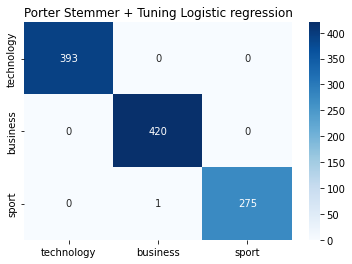

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Porter_tuning_LogReg,
                X_train_PorterStemmer,
                Y_train,
                'Porter Stemmer + Tuning Logistic regression',
                'train')

AUC-ROC Score: 99.9999


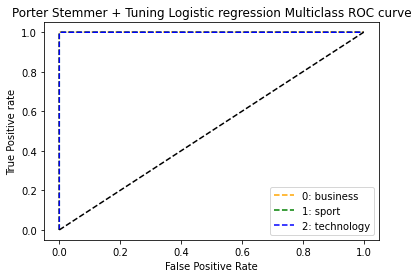

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Porter_tuning_LogReg,
             X_train_PorterStemmer,
             Y_train,
             'Porter Stemmer + Tuning Logistic regression',
             'train')

Test Score

Accuracy Score: 98.1685
Precision: 98.1799 
Recall: 98.1685
F1 Score: 98.1654


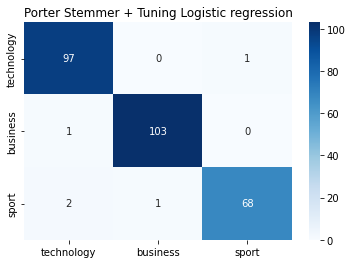

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Porter_tuning_LogReg,
                X_test_PorterStemmer,
                Y_test,
                'Porter Stemmer + Tuning Logistic regression',
                'test')

AUC-ROC Score: 99.7702


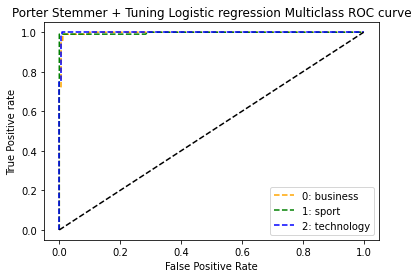

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Porter_tuning_LogReg,
             X_test_PorterStemmer,
             Y_test,
             'Porter Stemmer + Tuning Logistic regression',
             'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model K-Neighbors Classifier
Porter_tuning_KNN = tuning_KNN.fit(X_train_PorterStemmer, Y_train)
Porter_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 132 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   46.4s finished


{'algorithm': 'brute',
 'leaf_size': 30,
 'metric': 'minkowski',
 'n_jobs': -1,
 'n_neighbors': 13,
 'p': 2,
 'weights': 'distance'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


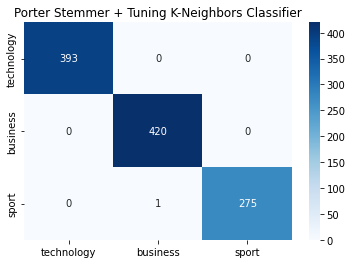

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Porter_tuning_KNN,
                X_train_PorterStemmer,
                Y_train,
                'Porter Stemmer + Tuning K-Neighbors Classifier',
                'train')

AUC-ROC Score: 99.9999


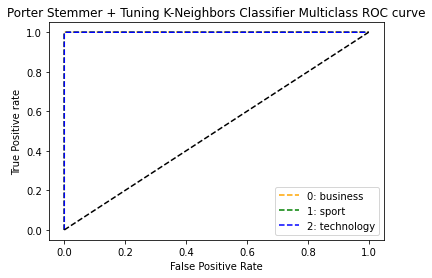

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Porter_tuning_KNN,
             X_train_PorterStemmer,
             Y_train,
             'Porter Stemmer + Tuning K-Neighbors Classifier',
             'train')

Test Score

Accuracy Score: 96.3370
Precision: 96.3422 
Recall: 96.3370
F1 Score: 96.3375


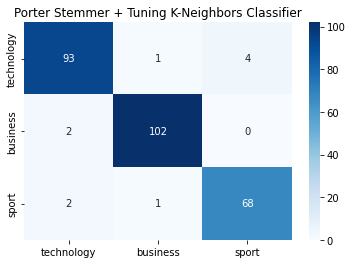

In [ ]:
# แสดง ROC Curve
get_conf_matrix(Porter_tuning_KNN,
                X_test_PorterStemmer,
                Y_test,
                'Porter Stemmer + Tuning K-Neighbors Classifier',
                'test')

AUC-ROC Score: 99.2457


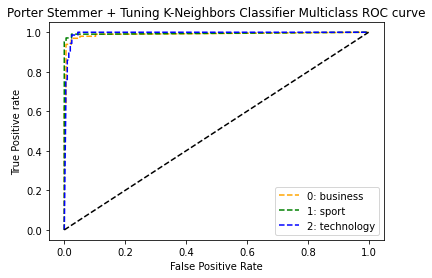

In [ ]:
# แสดง confusion matrix
get_ROC_curv(Porter_tuning_KNN,
             X_test_PorterStemmer,
             Y_test,
             'Porter Stemmer + Tuning K-Neighbors Classifier',
             'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model Multinomial Naive Bayes
Porter_tuning_MultiNB = tuning_MultiNB.fit(X_train_PorterStemmer, Y_train)
Porter_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.4s finished


{'alpha': 0.5, 'fit_prior': False}

Train Score

Accuracy Score: 99.1736
Precision: 99.1758 
Recall: 99.1736
F1 Score: 99.1741


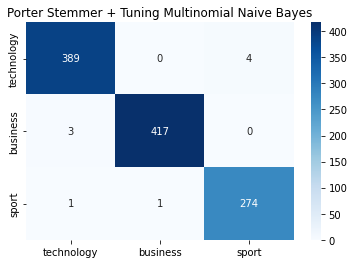

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Porter_tuning_MultiNB,
                X_train_PorterStemmer,
                Y_train,
                'Porter Stemmer + Tuning Multinomial Naive Bayes',
                'train')

AUC-ROC Score: 99.9370


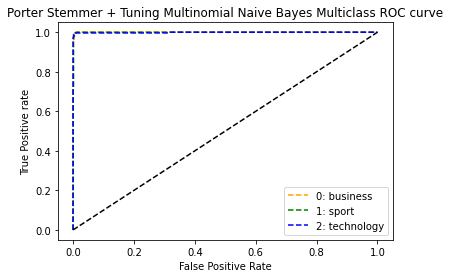

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Porter_tuning_MultiNB,
             X_train_PorterStemmer,
             Y_train,
             'Porter Stemmer + Tuning Multinomial Naive Bayes',
             'train')

Test Score

Accuracy Score: 97.4359
Precision: 97.4512 
Recall: 97.4359
F1 Score: 97.4378


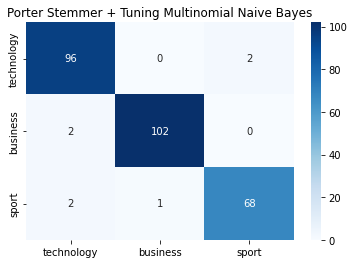

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Porter_tuning_MultiNB,
                X_test_PorterStemmer,
                Y_test,
                'Porter Stemmer + Tuning Multinomial Naive Bayes',
                'test')

AUC-ROC Score: 99.7549


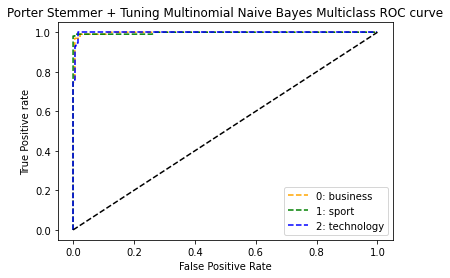

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Porter_tuning_MultiNB,
             X_test_PorterStemmer,
             Y_test,
             'Porter Stemmer + Tuning Multinomial Naive Bayes',
             'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model Linear Support Vector Classification
Porter_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(X_train_PorterStemmer, Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.3s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.7s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.1s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.4s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.8s finished


Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


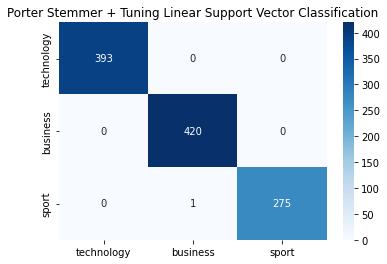

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Porter_tuning_LinSVC,
                X_train_PorterStemmer,
                Y_train,
                'Porter Stemmer + Tuning Linear Support Vector Classification',
                'train')

AUC-ROC Score: 99.9994


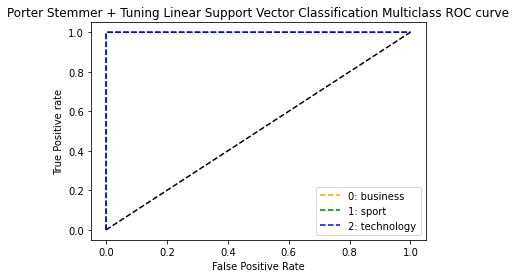

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Porter_tuning_LinSVC,
             X_train_PorterStemmer,
             Y_train,
             'Porter Stemmer + Tuning Linear Support Vector Classification',
             'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


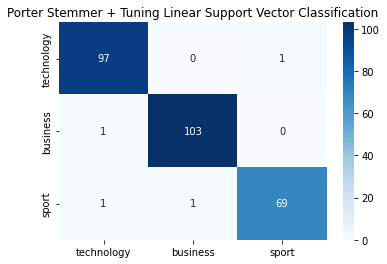

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Porter_tuning_LinSVC,
                X_test_PorterStemmer,
                Y_test,
                'Porter Stemmer + Tuning Linear Support Vector Classification',
                'test')

AUC-ROC Score: 99.7289


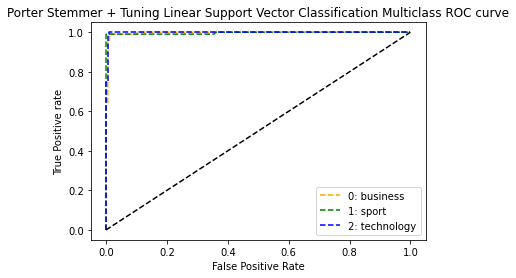

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Porter_tuning_LinSVC,
             X_test_PorterStemmer,
             Y_test,
             'Porter Stemmer + Tuning Linear Support Vector Classification',
             'test')

### 3: ใช้ Tuning Model ทำ Text Classification กับ Text ที่ normalize ด้วย Snowball Stemmer

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model Logistic regression
Snowball_tuning_LogReg = tuning_LogReg.fit(X_train_SnowballStemmer, Y_train)
Snowball_tuning_LogReg.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    6.6s finished


{'C': 1291.5496650148827, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


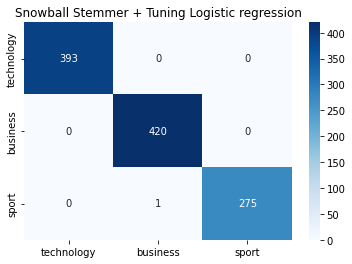

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_LogReg,
                X_train_SnowballStemmer,
                Y_train,
                'Snowball Stemmer + Tuning Logistic regression',
                'train')

AUC-ROC Score: 99.9999


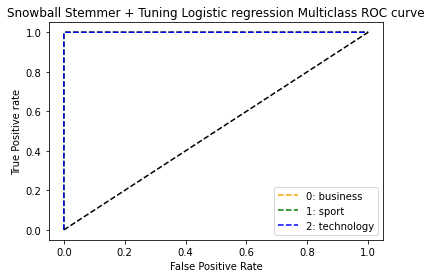

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_LogReg,
             X_train_SnowballStemmer,
             Y_train,
             'Snowball Stemmer + Tuning Logistic regression',
             'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5515 
Recall: 98.5348
F1 Score: 98.5374


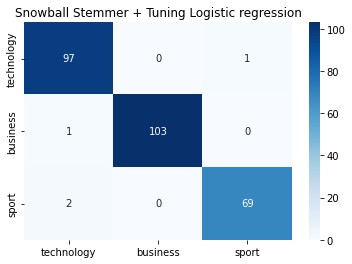

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_LogReg,
                X_test_SnowballStemmer,
                Y_test,
                'Snowball Stemmer + Tuning Logistic regression',
                'test')

AUC-ROC Score: 99.7435


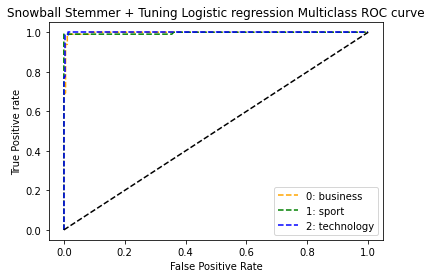

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_LogReg,
             X_test_SnowballStemmer,
             Y_test,
             'Snowball Stemmer + Tuning Logistic regression',
             'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model K-Neighbors Classifier
Snowball_tuning_KNN = tuning_KNN.fit(X_train_SnowballStemmer, Y_train)
Snowball_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 132 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   44.6s finished


{'algorithm': 'brute',
 'leaf_size': 30,
 'metric': 'minkowski',
 'n_jobs': -1,
 'n_neighbors': 15,
 'p': 2,
 'weights': 'uniform'}

Train Score

Accuracy Score: 97.9798
Precision: 98.0150 
Recall: 97.9798
F1 Score: 97.9825


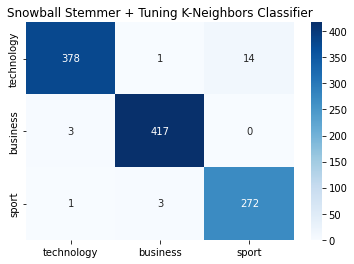

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_KNN,
                X_train_SnowballStemmer,
                Y_train,
                'Snowball Stemmer + Tuning K-Neighbors Classifier',
                'train')

AUC-ROC Score: 99.8610


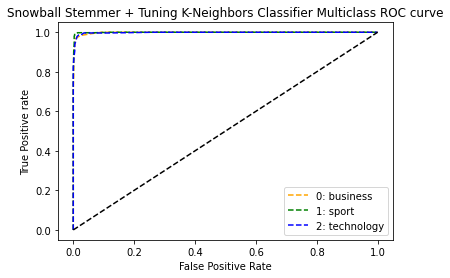

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_KNN,
             X_train_SnowballStemmer,
             Y_train,
             'Snowball Stemmer + Tuning K-Neighbors Classifier',
             'train')

Test Score

Accuracy Score: 95.9707
Precision: 95.9661 
Recall: 95.9707
F1 Score: 95.9666


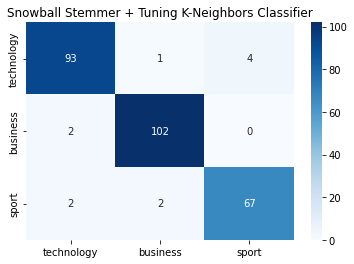

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_KNN,
                X_test_SnowballStemmer,
                Y_test,
                'Snowball Stemmer + Tuning K-Neighbors Classifier',
                'test')

AUC-ROC Score: 99.1323


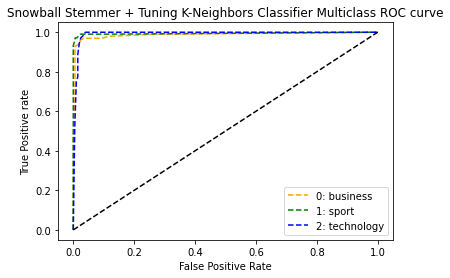

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_KNN,
             X_test_SnowballStemmer,
             Y_test,
             'Snowball Stemmer + Tuning K-Neighbors Classifier',
             'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model Multinomial Naive Bayes
Snowball_tuning_MultiNB = tuning_MultiNB.fit(X_train_SnowballStemmer, Y_train)
Snowball_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.4s finished


{'alpha': 0.5, 'fit_prior': True}

Train Score

Accuracy Score: 98.9899
Precision: 98.9911 
Recall: 98.9899
F1 Score: 98.9895


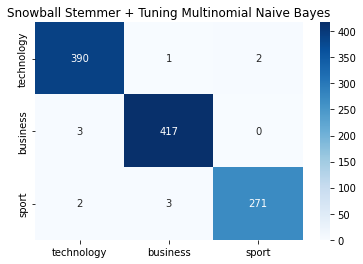

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_MultiNB,
                X_train_SnowballStemmer,
                Y_train,
                'Snowball Stemmer + Tuning Multinomial Naive Bayes',
                'train')

AUC-ROC Score: 99.9307


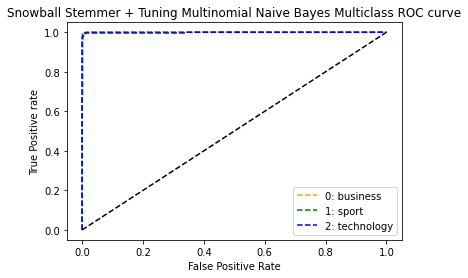

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_MultiNB,
             X_train_SnowballStemmer,
             Y_train,
             'Snowball Stemmer + Tuning Multinomial Naive Bayes',
             'train')

Test Score

Accuracy Score: 97.0696
Precision: 97.1509 
Recall: 97.0696
F1 Score: 97.0670


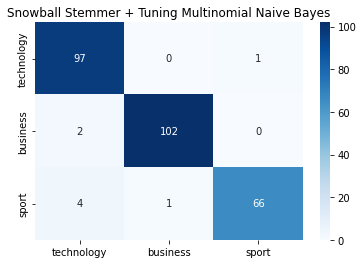

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_MultiNB,
                X_test_SnowballStemmer,
                Y_test,
                'Snowball Stemmer + Tuning Multinomial Naive Bayes',
                'test')

AUC-ROC Score: 99.7392


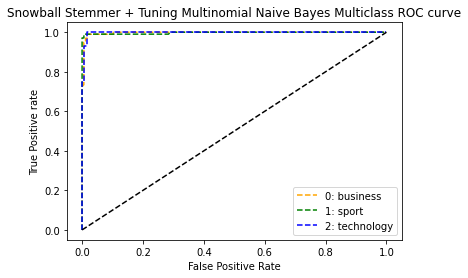

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_MultiNB,
             X_test_SnowballStemmer,
             Y_test,
             'Snowball Stemmer + Tuning Multinomial Naive Bayes',
             'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model Linear Support Vector Classification
Snowball_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(X_train_SnowballStemmer, Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.7s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.7s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.2s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.4s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 182 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.9s finished


Train Score

Accuracy Score: 99.8163
Precision: 99.8166 
Recall: 99.8163
F1 Score: 99.8163


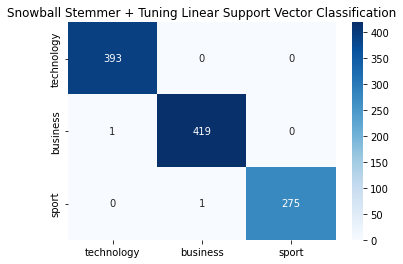

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_LinSVC,
                X_train_SnowballStemmer,
                Y_train,
                'Snowball Stemmer + Tuning Linear Support Vector Classification',
                'train')

AUC-ROC Score: 99.9994


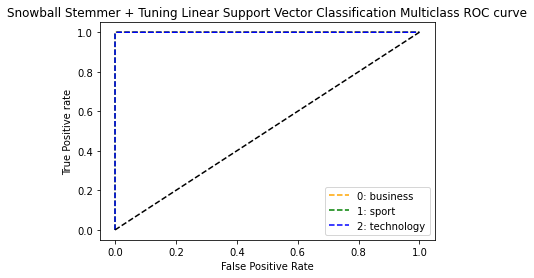

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_LinSVC,
             X_train_SnowballStemmer,
             Y_train,
             'Snowball Stemmer + Tuning Linear Support Vector Classification',
             'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


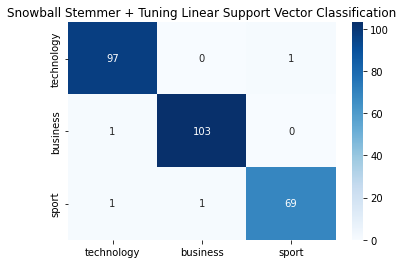

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Snowball_tuning_LinSVC,
                X_test_SnowballStemmer,
                Y_test,
                'Snowball Stemmer + Tuning Linear Support Vector Classification',
                'test')

AUC-ROC Score: 99.7085


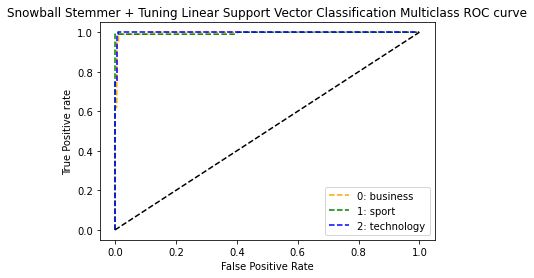

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Snowball_tuning_LinSVC,
             X_test_SnowballStemmer,
             Y_test,
             'Snowball Stemmer + Tuning Linear Support Vector Classification',
             'test')

### 4: ใช้ Tuning Model ทำ Text Classification กับ Text ที่ normalize ด้วย Lancaster Stemmer

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model Logistic regression
Lancaster_tuning_LogReg = tuning_LogReg.fit(X_train_LancasterStemmer, Y_train)
Lancaster_tuning_LogReg.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    7.4s finished


{'C': 464.15888336127773, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


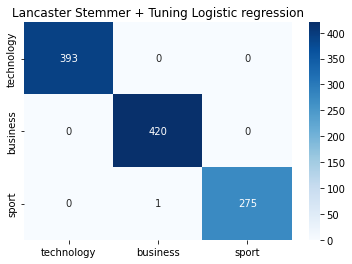

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_LogReg,
                X_train_LancasterStemmer,
                Y_train,
                'Lancaster Stemmer + Tuning Logistic regression',
                'train')

AUC-ROC Score: 99.9999


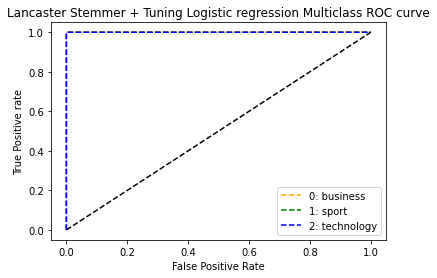

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_LogReg,
             X_train_LancasterStemmer,
             Y_train,
             'Lancaster Stemmer + Tuning Logistic regression',
             'train')

Test Score

Accuracy Score: 98.1685
Precision: 98.1723 
Recall: 98.1685
F1 Score: 98.1635


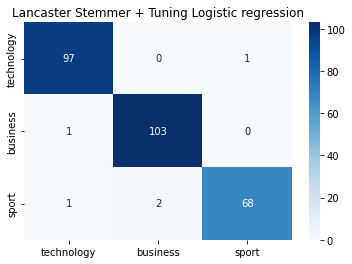

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_LogReg,
                X_test_LancasterStemmer,
                Y_test,
                'Lancaster Stemmer + Tuning Logistic regression',
                'test')

AUC-ROC Score: 99.8095


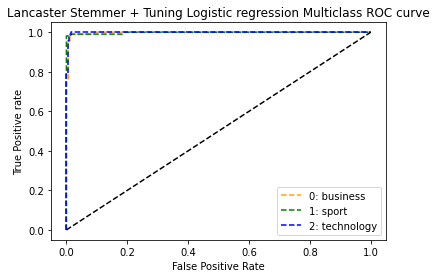

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_LogReg,
             X_test_LancasterStemmer,
             Y_test,
             'Lancaster Stemmer + Tuning Logistic regression',
             'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model K-Neighbors Classifier
Lancaster_tuning_KNN = tuning_KNN.fit(X_train_LancasterStemmer, Y_train)
Lancaster_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 132 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   48.6s finished
/usr/local/lib/python3.7/dist-packages/sklearn/neighbors/_base.py:414: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: "


{'algorithm': 'kd_tree',
 'leaf_size': 60,
 'metric': 'minkowski',
 'n_jobs': -1,
 'n_neighbors': 17,
 'p': 2,
 'weights': 'distance'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


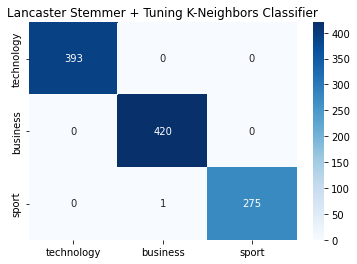

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_KNN,
                X_train_LancasterStemmer,
                Y_train,
                'Lancaster Stemmer + Tuning K-Neighbors Classifier',
                'train')

AUC-ROC Score: 99.9999


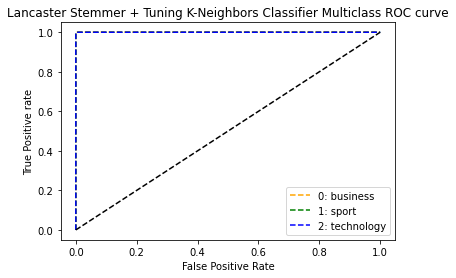

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_KNN,
             X_train_LancasterStemmer,
             Y_train,
             'Lancaster Stemmer + Tuning K-Neighbors Classifier',
             'train')

Test Score

Accuracy Score: 96.3370
Precision: 96.3529 
Recall: 96.3370
F1 Score: 96.3310


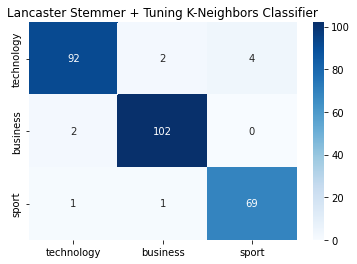

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_KNN,
                X_test_LancasterStemmer,
                Y_test,
                'Lancaster Stemmer + Tuning K-Neighbors Classifier',
                'test')

AUC-ROC Score: 99.2559


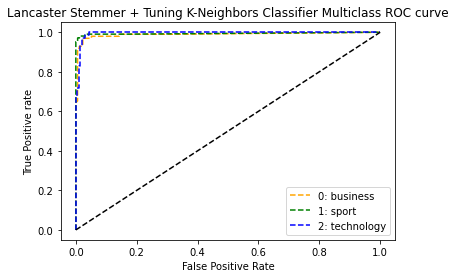

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_KNN,
             X_test_LancasterStemmer,
             Y_test,
             'Lancaster Stemmer + Tuning K-Neighbors Classifier',
             'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model Multinomial Naive Bayes
Lancaster_tuning_MultiNB = tuning_MultiNB.fit(X_train_LancasterStemmer, Y_train)
Lancaster_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.4s finished


{'alpha': 0.5, 'fit_prior': False}

Train Score

Accuracy Score: 99.1736
Precision: 99.1740 
Recall: 99.1736
F1 Score: 99.1737


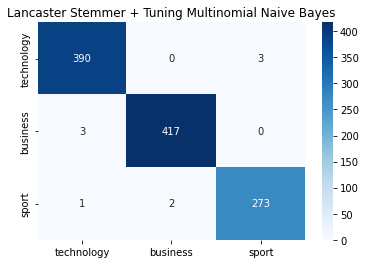

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_MultiNB,
                X_train_LancasterStemmer,
                Y_train,
                'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
                'train')

AUC-ROC Score: 99.9380


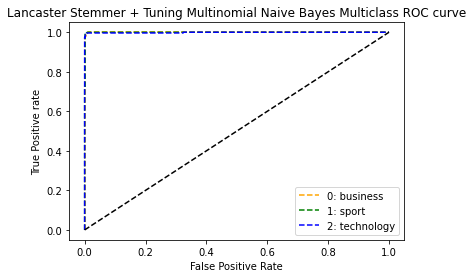

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_MultiNB,
             X_train_LancasterStemmer,
             Y_train,
             'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
             'train')

Test Score

Accuracy Score: 96.3370
Precision: 96.3794 
Recall: 96.3370
F1 Score: 96.3456


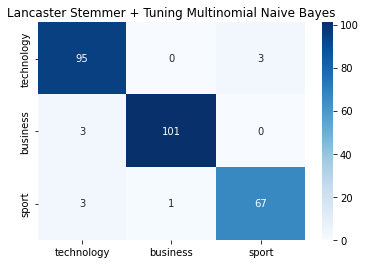

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_MultiNB,
                X_test_LancasterStemmer,
                Y_test,
                'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
                'test')

AUC-ROC Score: 99.7800


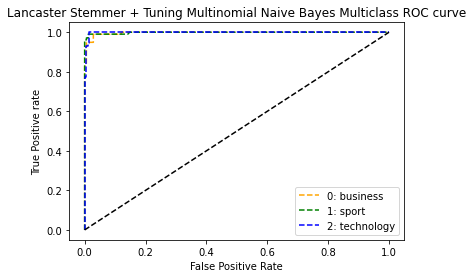

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_MultiNB,
             X_test_LancasterStemmer,
             Y_test,
             'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
             'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model Linear Support Vector Classification
Lancaster_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(X_train_LancasterStemmer, Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.3s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.6s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.5s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.1s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.9s finished


Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


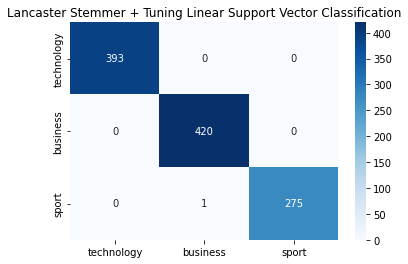

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_LinSVC,
                X_train_LancasterStemmer,
                Y_train,
                'Lancaster Stemmer + Tuning Linear Support Vector Classification',
                'train')

AUC-ROC Score: 99.9990


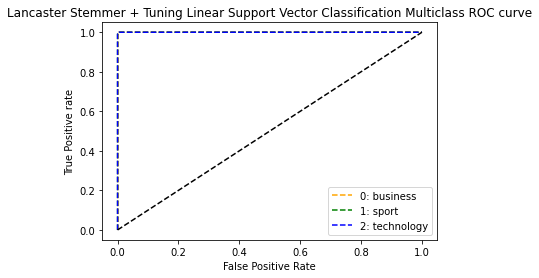

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_LinSVC,
             X_train_LancasterStemmer,
             Y_train,
             'Lancaster Stemmer + Tuning Linear Support Vector Classification',
             'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


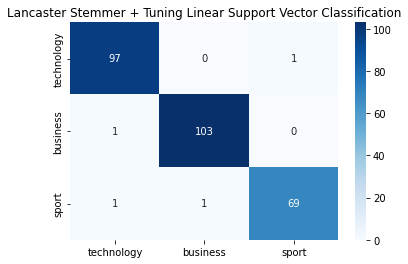

In [ ]:
# แสดง confusion matrix
get_conf_matrix(Lancaster_tuning_LinSVC,
                X_test_LancasterStemmer,
                Y_test,
                'Lancaster Stemmer + Tuning Linear Support Vector Classification',
                'test')

AUC-ROC Score: 99.7889


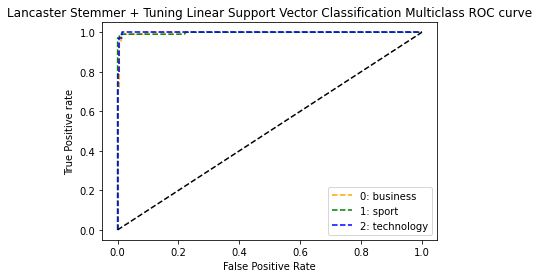

In [ ]:
# แสดง ROC Curve
get_ROC_curv(Lancaster_tuning_LinSVC,
             X_test_LancasterStemmer,
             Y_test,
             'Lancaster Stemmer + Tuning Linear Support Vector Classification',
             'test')

### 5: ใช้ Tuning Model ทำ Text Classification กับ Text ที่ normalize ด้วย Lemmatizer with POS

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model Logistic regression
lemma_w_pos_tuning_LogReg = tuning_LogReg.fit(X_train_Lemma_w_POS_Tag, Y_train)
lemma_w_pos_tuning_LogReg.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    6.4s finished


{'C': 464.15888336127773, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


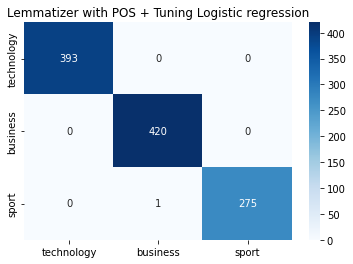

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_LogReg,
                X_train_Lemma_w_POS_Tag,
                Y_train,
                'Lemmatizer with POS + Tuning Logistic regression',
                'train')

AUC-ROC Score: 99.9999


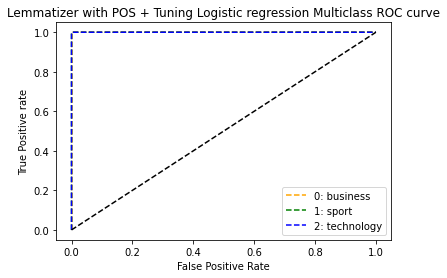

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_LogReg,
             X_train_Lemma_w_POS_Tag,
             Y_train,
             'Lemmatizer with POS + Tuning Logistic regression',
             'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


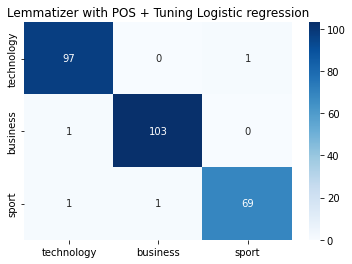

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_LogReg,
                X_test_Lemma_w_POS_Tag,
                Y_test,
                'Lemmatizer with POS + Tuning Logistic regression',
                'test')

AUC-ROC Score: 99.6707


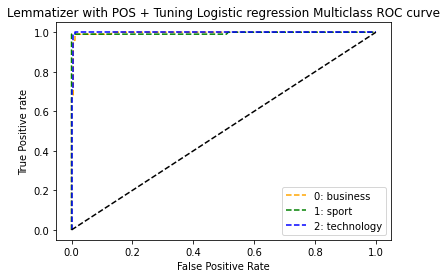

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_LogReg,
             X_test_Lemma_w_POS_Tag,
             Y_test,
             'Lemmatizer with POS + Tuning Logistic regression',
             'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model K-Neighbors Classifier
lemma_w_pos_tuning_KNN = tuning_KNN.fit(X_train_Lemma_w_POS_Tag, Y_train)
lemma_w_pos_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 134 tasks      | elapsed:   24.5s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   43.5s finished


{'algorithm': 'auto',
 'leaf_size': 40,
 'metric': 'euclidean',
 'n_jobs': -1,
 'n_neighbors': 19,
 'p': 2,
 'weights': 'distance'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


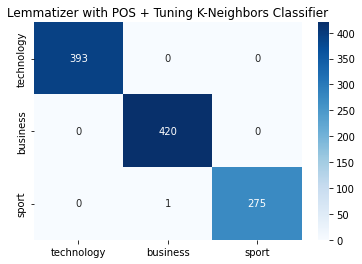

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_KNN,
                X_train_Lemma_w_POS_Tag,
                Y_train,
                'Lemmatizer with POS + Tuning K-Neighbors Classifier',
                'train')

AUC-ROC Score: 99.9999


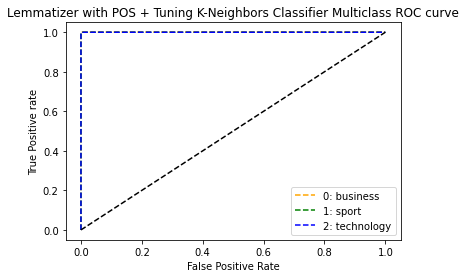

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_KNN,
             X_train_Lemma_w_POS_Tag,
             Y_train,
             'Lemmatizer with POS + Tuning K-Neighbors Classifier',
             'train')

Test Score

Accuracy Score: 96.7033
Precision: 96.7134 
Recall: 96.7033
F1 Score: 96.6959


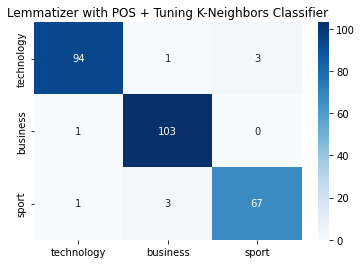

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_KNN,
                X_test_Lemma_w_POS_Tag,
                Y_test,
                'Lemmatizer with POS + Tuning K-Neighbors Classifier',
                'test')

AUC-ROC Score: 99.1997


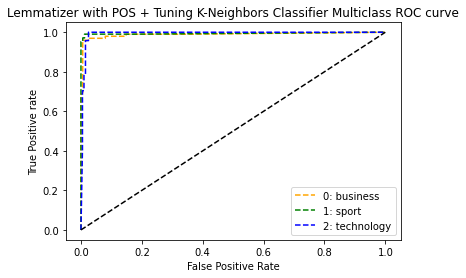

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_KNN,
             X_test_Lemma_w_POS_Tag,
             Y_test,
             'Lemmatizer with POS + Tuning K-Neighbors Classifier',
             'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model Multinomial Naive Bayes
lemma_w_pos_tuning_MultiNB = tuning_MultiNB.fit(X_train_Lemma_w_POS_Tag, Y_train)
lemma_w_pos_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.4s finished


{'alpha': 0.9, 'fit_prior': False}

Train Score

Accuracy Score: 98.8981
Precision: 98.8980 
Recall: 98.8981
F1 Score: 98.8979


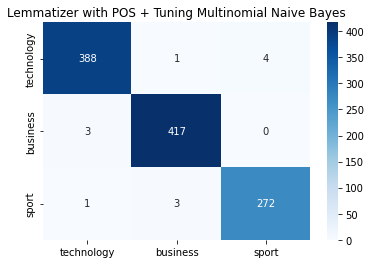

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_MultiNB,
                X_train_Lemma_w_POS_Tag,
                Y_train,
                'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
                'train')

AUC-ROC Score: 99.9173


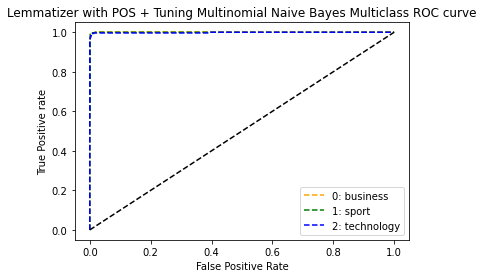

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_MultiNB,
             X_train_Lemma_w_POS_Tag,
             Y_train,
             'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
             'train')

Test Score

Accuracy Score: 97.4359
Precision: 97.4476 
Recall: 97.4359
F1 Score: 97.4396


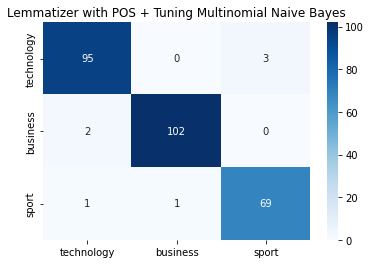

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_MultiNB,
                X_test_Lemma_w_POS_Tag,
                Y_test,
                'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
                'test')

AUC-ROC Score: 99.7126


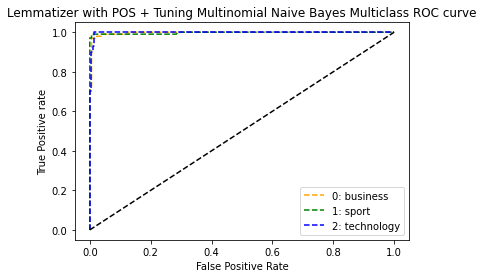

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_MultiNB,
             X_test_Lemma_w_POS_Tag,
             Y_test,
             'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
             'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model Linear Support Vector Classification
lemma_w_pos_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(X_train_Lemma_w_POS_Tag, Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.0s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 182 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.5s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.6s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    5.6s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    6.1s finished


Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


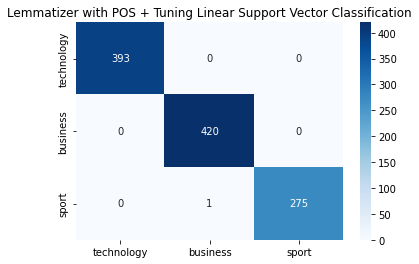

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_LinSVC,
                X_train_Lemma_w_POS_Tag,
                Y_train,
                'Lemmatizer with POS + Tuning Linear Support Vector Classification',
                'train')

AUC-ROC Score: 99.9989


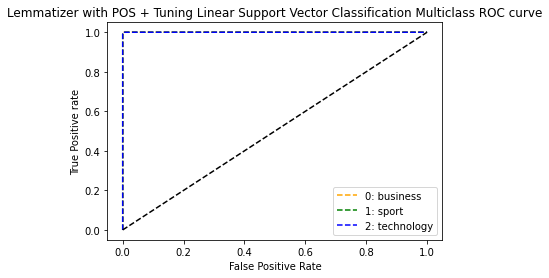

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_LinSVC,
             X_train_Lemma_w_POS_Tag,
             Y_train,
             'Lemmatizer with POS + Tuning Linear Support Vector Classification',
             'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


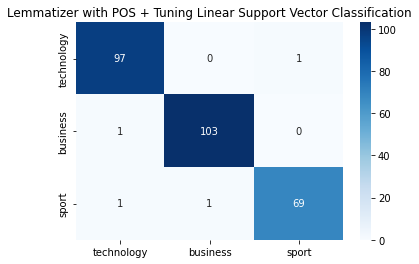

In [ ]:
# แสดง confusion matrix
get_conf_matrix(lemma_w_pos_tuning_LinSVC,
                X_test_Lemma_w_POS_Tag,
                Y_test,
                'Lemmatizer with POS + Tuning Linear Support Vector Classification',
                'test')

AUC-ROC Score: 99.6497


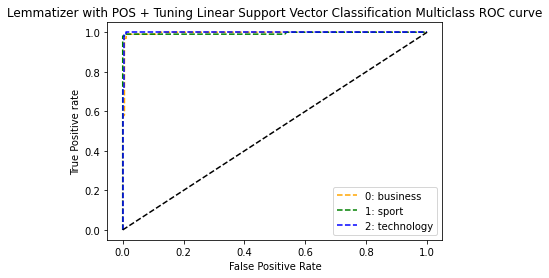

In [ ]:
# แสดง ROC Curve
get_ROC_curv(lemma_w_pos_tuning_LinSVC,
             X_test_Lemma_w_POS_Tag,
             Y_test,
             'Lemmatizer with POS + Tuning Linear Support Vector Classification',
             'test')

### 6: All Tuning Model Score

นำเอา score ที่ได้จาก model ต่างๆ มาทำเป็น dataframe เพื่อเปรียบเทียบ score ของแต่ละ model

In [ ]:
# นำเอาข้อมูล dict เก็บ score ที่ได้มาสร้างเป็น dataframe
Score_df = pd.DataFrame(all_score)
Score_df

,Model_Name,Train_Accuracy_Score,Test_Accuracy_Score,Train_ROC_AUC_Score,Test_ROC_AUC_Score,Train_Precision_Score,Test_Precision_Score,Train_Recall_Score,Test_Recall_Score,Train_F1_Score,Test_F1_Score
0,Porter Stemmer + Tuning Logistic regression,99.908173,98.168498,99.999862,99.770241,99.908391,98.179859,99.908173,98.168498,99.908144,98.165432
1,Porter Stemmer + Tuning K-Neighbors Classifier,99.908173,96.336996,99.999862,99.245683,99.908391,96.342241,99.908173,96.336996,99.908144,96.337509
2,Porter Stemmer + Tuning Multinomial Naive Bayes,99.173554,97.435897,99.937002,99.754919,99.175757,97.451179,99.173554,97.435897,99.174110,97.437848
3,Porter Stemmer + Tuning Linear Support Vector ...,99.908173,98.534799,99.999449,99.728890,99.908391,98.536966,99.908173,98.534799,99.908144,98.533691
4,Snowball Stemmer + Tuning Logistic regression,99.908173,98.534799,99.999862,99.743464,99.908391,98.551544,99.908173,98.534799,99.908144,98.537417
5,Snowball Stemmer + Tuning K-Neighbors Classifier,97.979798,95.970696,99.860985,99.132336,98.015044,95.966057,97.979798,95.970696,97.982504,95.966624
6,Snowball Stemmer + Tuning Multinomial Naive Bayes,98.989899,97.069597,99.930735,99.739156,98.991078,97.150862,98.989899,97.069597,98.989457,97.066982
7,Snowball Stemmer + Tuning Linear Support Vecto...,99.816345,98.534799,99.999449,99.708501,99.816578,98.536966,99.816345,98.534799,99.816320,98.533691
8,Lancaster Stemmer + Tuning Logistic regression,99.908173,98.168498,99.999862,99.809491,99.908391,98.172258,99.908173,98.168498,99.908144,98.163450
9,Lancaster Stemmer + Tuning K-Neighbors Classifier,99.908173,96.336996,99.999862,99.255851,99.908391,96.352902,99.908173,96.336996,99.908144,96.331018


 สรุป

1.   ผลลัพธ์จากการทำ Text Classification พบว่า model ที่มีค่า Accuracy Score  จากชุดข้อมูล Test มากกว่า 97.5 % คือ Logistic regression และ Linear Support Vector Classification ทำให้อาจสรุปได้ว่า Logistic regression และ Linear Support Vector Classification มีความเหมาะสมในการทำ Text Classification กับข้อมูลชุดนี้มากกว่า K-Neighbors Classifier และ Multinomial Naive Bayes
2.   ผลลัพธ์จากกการทำ Text Normalization ด้วย Snowball Stemmer และ Lemmatizer with POS เมื่อใช้ร่วมกันกับ Model Logistic regression และ Linear Support Vector Classification แล้ว ให้ค่า Accuracy Score ของข้อมูลชุด Test อยู่ที่ 98.534799 % ซึ่งถือได้ว่าเป็น Accuracy Score ที่สูงที่สุดของข้อมูลชุด test

## Task 5.2 Text Classification with Tuning Model and Vectorizer

ต้องการทดสอบว่าการ tune parameter ของ model และ vectorizer นั่นจะสามารถเพิ่มความแม่นยำในการ predict ข้อมูลชุด test ของ model K-Neighbors Classifier และ Multinomial Naive Bayesให้เกิน 97.5 % ได้หรือไม่ โดยจะกำหนดให้ใช้ Porter Stemmer ในการ normalize text และจะมีการใช้ model Logistic regression และ Linear Support Vector Classification มาใช้ในการ ทำ text classification ด้วยเพื่อเปรียบเทียบผลลัพธ์

In [ ]:
# import Pipeline เพื่อนำมาใช้กำหนดลำดับในการ Tuning Parameter
from sklearn.pipeline import Pipeline

### 1: Function เก็บ Score

In [ ]:
# สร้าง dict เพื่อเก็บ Score ของแต่ละ Model
all_tuning_score = {'Model_Name': [],
                    'Train_Accuracy_Score': [],
                    'Test_Accuracy_Score': [],

                    'Train_ROC_AUC_Score': [],
                    'Test_ROC_AUC_Score': [],

                    'Train_Precision_Score': [],
                    'Test_Precision_Score': [],

                    'Train_Recall_Score': [],
                    'Test_Recall_Score': [],

                    'Train_F1_Score': [],
                    'Test_F1_Score': [],
                    }

# ทำการเก็บค่า score ที่ได้จาก function สร้าง Confusion matrix ลงใน dict
def save_score(name, AccSc, PreSc, ReSc, F1Sc, data_name):

  # list สำหรับเก็บรายชื่อ model
  if name not in all_tuning_score['Model_Name']:
    all_tuning_score['Model_Name'].append(name)


  if data_name == 'train':

    # list สำหรับเก็บค่า Accuracy score
    all_tuning_score['Train_Accuracy_Score'].append(AccSc)
    # list สำหรับเก็บค่า Precision score
    all_tuning_score['Train_Precision_Score'].append(PreSc)
    # list สำหรับเก็บค่า Recall score
    all_tuning_score['Train_Recall_Score'].append(ReSc)
    # list สำหรับเก็บค่า F1 score
    all_tuning_score['Train_F1_Score'].append(F1Sc)


  elif data_name == 'test':
    # list สำหรับเก็บค่า Accuracy score
    all_tuning_score['Test_Accuracy_Score'].append(AccSc)
    # list สำหรับเก็บค่า Precision score
    all_tuning_score['Test_Precision_Score'].append(PreSc)
    # list สำหรับเก็บค่า Recall score
    all_tuning_score['Test_Recall_Score'].append(ReSc)
    # list สำหรับเก็บค่า F1 score
    all_tuning_score['Test_F1_Score'].append(F1Sc)

# ทำการเก็บค่า score ที่ได้จาก function สร้าง ROC_Curve ลงใน dict
def save_ROC_AUC_score(ROC_AUC_Sc, data_name):
  # ทำการเก็บค่า score ที่ได้ลงใน list
  if data_name == 'train':
    all_tuning_score['Train_ROC_AUC_Score'].append(ROC_AUC_Sc)
  elif data_name == 'test':
    all_tuning_score['Test_ROC_AUC_Score'].append(ROC_AUC_Sc)

### 2: Tuning TfidfVectorizer และ Tuning LogisticRegression

In [ ]:
# function สำหรับทำการ tuning TfidfVectorizer และ LogisticRegression
def Tuning_Tfidf_LogReg(X, Y):
  pipeline = Pipeline([("tfidf", TfidfVectorizer()),
                     ("clf", LogisticRegression())]
                      )
  # parameters ขึ้นต้นด้วย tfidf__ ใช้ tuning TfidfVectorizer
  # parameters ขึ้นต้นด้วย clf__ ใช้ tuning LogisticRegression
  parameters = {'tfidf__tokenizer': [PorterStemmer_tokenizer],
                'tfidf__stop_words' : ['english'],
                'tfidf__ngram_range': [(1, 1), (1, 2)],
                'tfidf__min_df': [3, 4, 5],
                'tfidf__use_idf': [True, False],
                'tfidf__norm': ['l1', 'l2'],

                'clf__penalty': ['none', 'l1', 'l2', 'elasticnet'],
                'clf__C': np.logspace(0, 4, 10),
                'clf__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
                }

  # ทำ cross validation ด้วย Stratified K-Fold
  S_kFold = StratifiedKFold(n_splits = 5,
                            shuffle = True,
                            random_state = 1
                            )

  # ทำการ tuning model ด้วย Randomized Search CV
  pipe = RandomizedSearchCV(pipeline,
                            parameters,
                            n_iter = 50,
                            n_jobs = -1,
                            cv = S_kFold,
                            verbose = 3,
                            random_state = 0
                            )

  return pipe.fit(X, Y)

In [ ]:
# ส่งข้อมูล Text ที่ยังไม่ผ่านการ pre-process เข้าไปใน function เพื่อให้ function จัดการ text และทำ classification ตาม pipeline
tuning_tfidf_LogReg = Tuning_Tfidf_LogReg(X_train, Y_train)
tuning_tfidf_LogReg.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed: 14.7min
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed: 29.7min finished
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someo

Pipeline(memory=None,
         steps=[('tfidf',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=4, ngram_range=(1, 2), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words='english', strip_accents=None,
                                 sublinear_tf=False,
                                 token_patt...
                                 tokenizer=<function PorterStemmer_tokenizer at 0x7f963b207050>,
                                 use_idf=False, vocabulary=None)),
                ('clf',
                 LogisticRegression(C=2.7825594022071245, class_weight=None,
                                    d

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


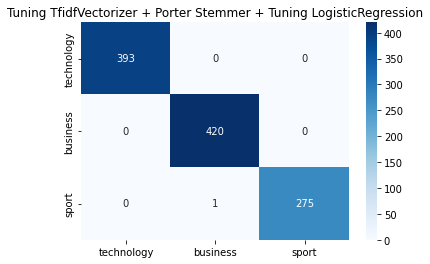

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_LogReg,
                X_train,
                Y_train,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning LogisticRegression',
                'train')

AUC-ROC Score: 99.9960


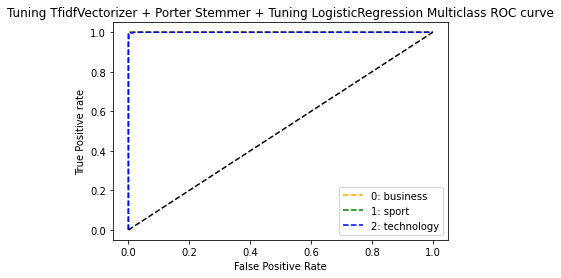

In [ ]:
# แสดง ROC Curve
get_ROC_curv(tuning_tfidf_LogReg,
             X_train,
             Y_train,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning LogisticRegression',
             'train')

Test Score

Accuracy Score: 97.4359
Precision: 97.4880 
Recall: 97.4359
F1 Score: 97.4355


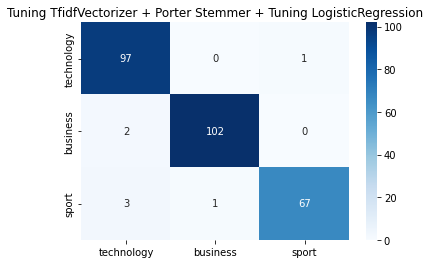

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_LogReg,
                X_test,
                Y_test,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning LogisticRegression',
                'test')

AUC-ROC Score: 99.7153


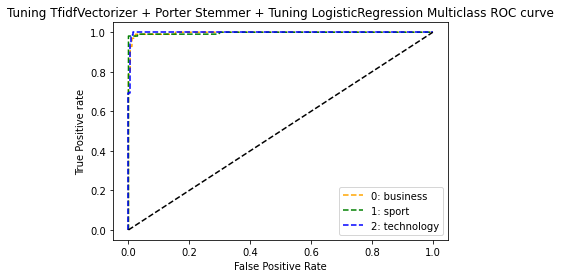

In [ ]:
# แสดง ROC Curve
get_ROC_curv(tuning_tfidf_LogReg,
             X_test,
             Y_test,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning LogisticRegression',
             'test')

### 3: Tuning TfidfVectorizer และ Tuning KNeighborsClassifier

In [ ]:
# function สำหรับทำการ tuning TfidfVectorizer และ KNeighborsClassifier
def Tuning_Tfidf_KNN(X, Y):
  pipeline = Pipeline([("tfidf", TfidfVectorizer()),
                     ("clf", KNeighborsClassifier())]
                      )

  # parameters ขึ้นต้นด้วย tfidf__ ใช้ tuning TfidfVectorizer
  # parameters ขึ้นต้นด้วย clf__ ใช้ tuning KNeighborsClassifier
  parameters = {'tfidf__tokenizer': [PorterStemmer_tokenizer],
                'tfidf__stop_words' : ['english'],
                'tfidf__ngram_range': [(1, 1), (1, 2)],
                'tfidf__min_df': [3, 4, 5],
                'tfidf__use_idf': [True, False],
                'tfidf__norm': ['l1', 'l2'],

                'clf__n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19, 21],
                'clf__weights': ['uniform', 'distance'],
                'clf__algorithm': ['auto', 'kd_tree', 'ball_tree', 'brute'],
                'clf__leaf_size': [30, 40, 50, 60],
                'clf__p': [1, 2],
                'clf__metric': ['minkowski', 'euclidean', 'manhattan'],
                'clf__n_jobs': [-1]
                }

  # ทำ cross validation ด้วย Stratified K-Fold
  S_kFold = StratifiedKFold(n_splits = 5,
                            shuffle = True,
                            random_state = 1
                            )

  # ทำการ tuning model ด้วย Randomized Search CV
  pipe = RandomizedSearchCV(pipeline,
                            parameters,
                            n_iter = 50,
                            n_jobs = -1,
                            cv = S_kFold,
                            verbose = 3,
                            random_state = 0
                            )

  return pipe.fit(X, Y)

In [ ]:
# ส่งข้อมูล Text ที่ยังไม่ผ่านการ pre-process เข้าไปใน function เพื่อให้ function จัดการ text และทำ classification ตาม pipeline
tuning_tfidf_KNN = Tuning_Tfidf_KNN(X_train, Y_train)
tuning_tfidf_KNN.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed: 16.4min
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed: 33.2min finished
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someo

Pipeline(memory=None,
         steps=[('tfidf',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=3, ngram_range=(1, 2), norm='l1',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words='english', strip_accents=None,
                                 sublinear_tf=False,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=<function PorterStemmer_tokenizer at 0x7f963b207050>,
                                 use_idf=False, vocabulary=None)),
                ('clf',
                 KNeighborsClassifier(algorithm='auto', leaf_size=60,
                       

Train Score

Accuracy Score: 98.2553
Precision: 98.2776 
Recall: 98.2553
F1 Score: 98.2585


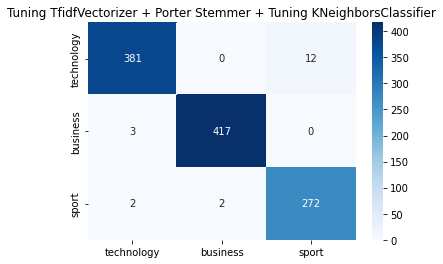

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_KNN,
                X_train,
                Y_train,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning KNeighborsClassifier',
                'train')

AUC-ROC Score: 99.9444


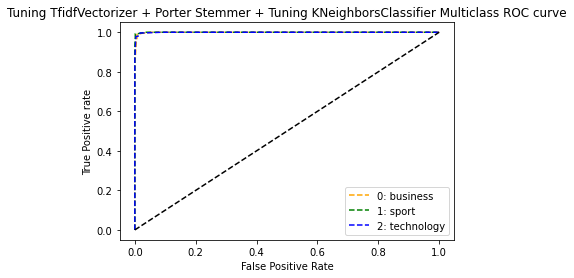

In [ ]:
# แสดง ROC Curve
get_ROC_curv(tuning_tfidf_KNN,
             X_train,
             Y_train,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning KNeighborsClassifier',
             'train')

Test Score

Accuracy Score: 97.4359
Precision: 97.4660 
Recall: 97.4359
F1 Score: 97.4453


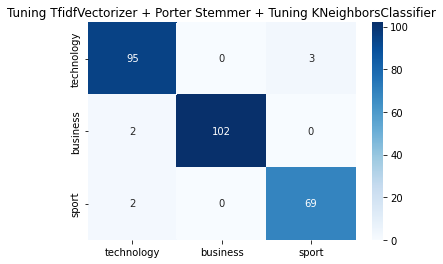

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_KNN,
                X_test,
                Y_test,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning KNeighborsClassifier',
                'test')

AUC-ROC Score: 99.4188


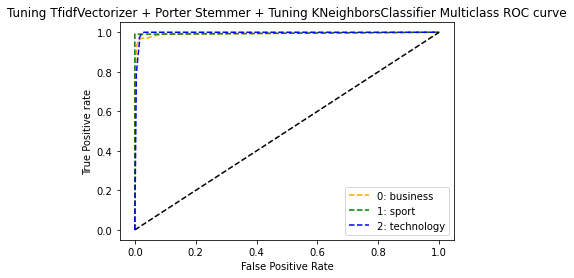

In [ ]:
# แสดง ROC Curve
get_ROC_curv(tuning_tfidf_KNN,
             X_test,
             Y_test,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning KNeighborsClassifier',
             'test')

### 4: Tuning TfidfVectorizer และ Tuning MultinomialNB

In [ ]:
# function สำหรับทำการ tuning TfidfVectorizer และ MultinomialNB
def Tuning_Tfidf_MultiNB(X, Y):
  pipeline = Pipeline([("tfidf", TfidfVectorizer()),
                     ("clf", MultinomialNB())]
                      )

  # parameters ขึ้นต้นด้วย tfidf__ ใช้ tuning TfidfVectorizer
  # parameters ขึ้นต้นด้วย clf__ ใช้ tuning MultinomialNB
  parameters = {'tfidf__tokenizer': [PorterStemmer_tokenizer],
                'tfidf__stop_words' : ['english'],
                'tfidf__ngram_range': [(1, 1), (1, 2)],
                'tfidf__min_df': [3, 4, 5],
                'tfidf__use_idf': [True, False],
                'tfidf__norm': ['l1', 'l2'],

                'clf__alpha': np.linspace(0.5, 1.5, 6),
                'clf__fit_prior': [True, False]
                }

  # ทำ cross validation ด้วย Stratified K-Fold
  S_kFold = StratifiedKFold(n_splits = 5,
                            shuffle = True,
                            random_state = 1
                            )

  # ทำการ tuning model ด้วย Randomized Search CV
  pipe = RandomizedSearchCV(pipeline,
                            parameters,
                            n_iter = 50,
                            n_jobs = -1,
                            cv = S_kFold,
                            verbose = 3,
                            random_state = 0
                            )

  return pipe.fit(X, Y)

In [ ]:
# ส่งข้อมูล Text ที่ยังไม่ผ่านการ pre-process เข้าไปใน function เพื่อให้ function จัดการ text และทำ classification ตาม pipeline
tuning_tfidf_MultiNB = Tuning_Tfidf_MultiNB(X_train, Y_train)
tuning_tfidf_MultiNB.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed: 16.3min
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed: 32.7min finished
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someo

Pipeline(memory=None,
         steps=[('tfidf',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=5, ngram_range=(1, 2), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words='english', strip_accents=None,
                                 sublinear_tf=False,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=<function PorterStemmer_tokenizer at 0x7f963b207050>,
                                 use_idf=True, vocabulary=None)),
                ('clf',
                 MultinomialNB(alpha=1.3, class_prior=None, fit_prior=True))],
         verbos

Train Score

Accuracy Score: 98.4389
Precision: 98.4431 
Recall: 98.4389
F1 Score: 98.4355


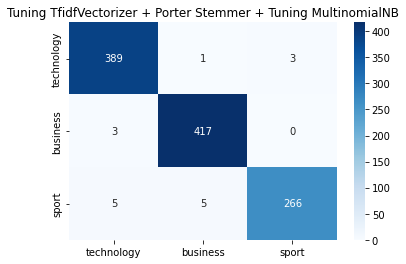

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_MultiNB,
                X_train,
                Y_train,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning MultinomialNB',
                'train')

AUC-ROC Score: 99.8834


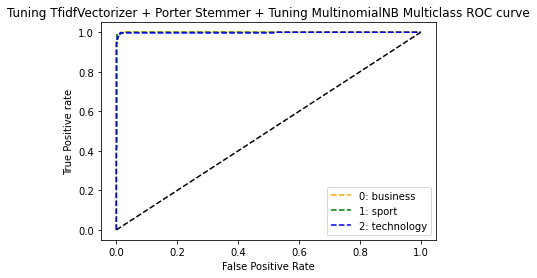

In [ ]:
# แสดง ROC Curve
get_ROC_curv(tuning_tfidf_MultiNB,
             X_train,
             Y_train,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning MultinomialNB',
             'train')

Test Score

Accuracy Score: 96.3370
Precision: 96.4142 
Recall: 96.3370
F1 Score: 96.3329


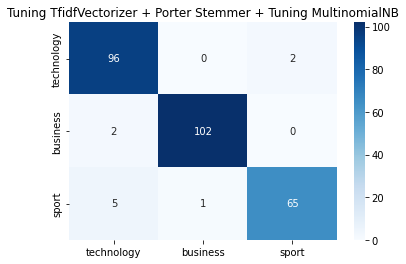

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_MultiNB,
                X_test,
                Y_test,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning MultinomialNB',
                'test')

AUC-ROC Score: 99.7268


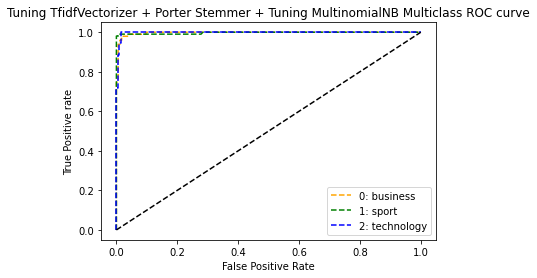

In [ ]:
# แสดง ROC Curve
get_ROC_curv(tuning_tfidf_MultiNB,
             X_test,
             Y_test,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning MultinomialNB',
             'test')

### 5: Tuning TfidfVectorizer และ Tuning LinearSVC

In [ ]:
# function สำหรับทำการ tuning TfidfVectorizer และ LinearSVC
def Tuning_Tfidf_LinSVC(X, Y):
  pipeline = Pipeline([("tfidf", TfidfVectorizer()),
                     ("clf", LinearSVC())
                     ])

  # parameters ขึ้นต้นด้วย tfidf__ ใช้ tuning TfidfVectorizer
  # parameters ขึ้นต้นด้วย clf__ ใช้ tuning LinearSVC
  parameters = {'tfidf__tokenizer': [PorterStemmer_tokenizer],
                'tfidf__stop_words' : ['english'],
                'tfidf__ngram_range': [(1, 1), (1, 2)],
                'tfidf__min_df': [3, 4, 5],
                'tfidf__use_idf': [True, False],
                'tfidf__norm': ['l1', 'l2'],

                'clf__penalty': ['l1', 'l2'],
                'clf__loss': ['hinge', 'squared_hinge'],
                'clf__dual': [False, True],
                'clf__max_iter': [1000, 5000, 10000, 20000, 50000, 150000]
                }

  # ทำ cross validation ด้วย Stratified K-Fold
  S_kFold = StratifiedKFold(n_splits = 5,
                            shuffle = True,
                            random_state = 1
                            )

  # ทำการ tuning model ด้วย Randomized Search CV
  pipe = RandomizedSearchCV(pipeline,
                            parameters,
                            n_iter = 50,
                            n_jobs = -1,
                            cv = S_kFold,
                            verbose = 3,
                            random_state = 0
                            )

  return pipe.fit(X, Y)

In [ ]:
# ส่งข้อมูล Text ที่ยังไม่ผ่านการ pre-process เข้าไปใน function เพื่อให้ function จัดการ text และทำ classification ตาม pipeline
tuning_tfidf_LinSVC = Tuning_Tfidf_LinSVC(X_train, Y_train)
tuning_tfidf_LinSVC.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed: 14.5min
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed: 29.8min finished
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someo

Pipeline(memory=None,
         steps=[('tfidf',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=3, ngram_range=(1, 2), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words='english', strip_accents=None,
                                 sublinear_tf=False,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=<function PorterStemmer_tokenizer at 0x7f963b207050>,
                                 use_idf=True, vocabulary=None)),
                ('clf',
                 LinearSVC(C=1.0, class_weight=None, dual=False,
                           fi

ทำการ fit ข้อมูลอีกครั้งพร้อมกับทำ CalibratedClassifierCV เนื่องจาก CalibratedClassifierCV ไม่สามารถใช้ร่วมกับการทำ Hyperparameter tuning ได้ จึงต้องทำการดู parameter ที่ได้จากการ tuning และนำมาใช้ในการกำหนด parameter ให้ model และ TfidfVectorizer ใหม่และทำการ fit ข้อมูลอีกครั้ง

In [ ]:
# ทำการปรับ parameter ของ TfidfVectorizer ตามที่ได้จาก tuning model
new_TfidfVectorizer = TfidfVectorizer(min_df = 3,
                                      ngram_range = (1, 2),
                                      norm = 'l2',
                                      stop_words = "english",
                                      tokenizer = PorterStemmer_tokenizer,
                                      use_idf = True)
# ทำการปรับ parameter ของ LinearSVC ตามที่ได้จาก tuning model
new_tuning_tfidf_LinSVC = LinearSVC(dual = False,
                              loss ='squared_hinge',
                              max_iter = 5000,
                              penalty = 'l2')

# ทำการ Vectorizer ข้อมูลใหม่อีกครั้ง
new_TfidfVectorizer.fit(X_train)
new_X_train = new_TfidfVectorizer.transform(X_train)
new_X_test = new_TfidfVectorizer.transform(X_test)

# ทำการ fit ข้อมูลใหม่อีกครั้ง
cal_tuning_tfidf_LinSVC = CalibratedClassifierCV(new_tuning_tfidf_LinSVC).fit(new_X_train, Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher',

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


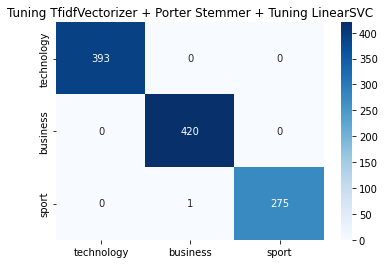

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_LinSVC,
                X_train,
                Y_train,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning LinearSVC',
                'train')

AUC-ROC Score: 99.9999


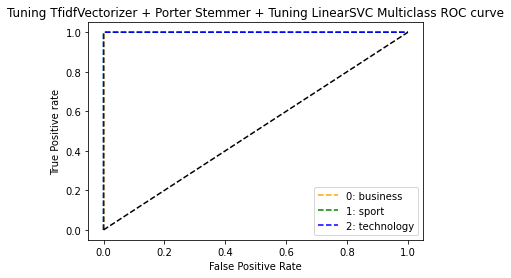

In [ ]:
# แสดง ROC Curve
get_ROC_curv(cal_tuning_tfidf_LinSVC,
             new_X_train,
             Y_train,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning LinearSVC',
             'train')

Test Score

Accuracy Score: 98.1685
Precision: 98.1799 
Recall: 98.1685
F1 Score: 98.1654


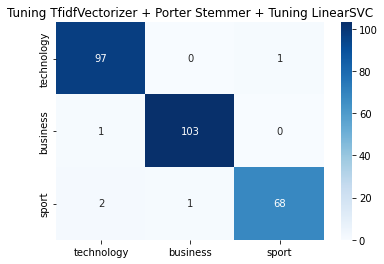

In [ ]:
# แสดง confusion matrix
get_conf_matrix(tuning_tfidf_LinSVC,
                X_test,
                Y_test,
                'Tuning TfidfVectorizer + Porter Stemmer + Tuning LinearSVC',
                'test')

AUC-ROC Score: 99.7394


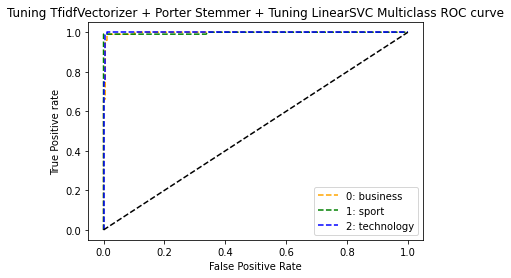

In [ ]:
# แสดง ROC Curve
get_ROC_curv(cal_tuning_tfidf_LinSVC,
             new_X_test,
             Y_test,
             'Tuning TfidfVectorizer + Porter Stemmer + Tuning LinearSVC',
             'test')

### 6: All Tuning Vectorizer and  Tuning Model Score

นำเอา score ที่ได้จาก model ต่างๆ มาทำเป็น dataframe เพื่อเปรียบเทียบ score ของแต่ละ model

In [ ]:
# นำเอาข้อมูล dict เก็บ score ที่ได้มาสร้างเป็น dataframe
tuning_Score_df = pd.DataFrame(all_tuning_score)
tuning_Score_df

,Model_Name,Train_Accuracy_Score,Test_Accuracy_Score,Train_ROC_AUC_Score,Test_ROC_AUC_Score,Train_Precision_Score,Test_Precision_Score,Train_Recall_Score,Test_Recall_Score,Train_F1_Score,Test_F1_Score
0,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,99.908173,97.435897,99.995961,99.715298,99.908391,97.488004,99.908173,97.435897,99.908144,97.435457
1,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,98.255280,97.435897,99.944383,99.418837,98.277556,97.465960,98.255280,97.435897,98.258487,97.445253
2,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,98.438935,96.336996,99.883357,99.726753,98.443075,96.414174,98.438935,96.336996,98.435529,96.332876
3,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,99.908173,98.168498,99.999862,99.739371,99.908391,98.179859,99.908173,98.168498,99.908144,98.165432


 สรุป

1.   ผลลัพธ์จากการทำ Text Classification พบว่า model ที่มีค่า Accuracy Score  จากชุดข้อมูล Test มากกว่า 97.5 % ยังคงเป็น Logistic regression และ Linear Support Vector Classification แม้จะมีการ tune parameter ของ model และ vectorizer แล้วก็ตาม ซึ่งอาจจะทำให้สรุปได้ว่าจริงๆ ว่า Logistic regression และ Linear Support Vector Classification มีความเหมาะสมในการทำ Text Classification กับข้อมูลชุดนี้มากกว่า K-Neighbors Classifier และ Multinomial Naive Bayes จริงๆ
2.   ผลลัพธ์จากกการ tune parameter ของ model และ vectorizer เมื่อเทียบกับการ tune parameter ของ model เพียงอย่างเดียวแล้ว พบว่าส่วนใหญ่จะได้ค่า Accuracy Score ของชุดข้อมูล Train และ Test จะเพิ่มขึ้น แต่มีเพียง model Multinomial Naive Bayes เท่านั้นที่ได้ค่า Accuracy Score ของข้อมูล Train และ Test ลดลงเมื่อเทียบกับการ tune parameter ของ model เพียงอย่างเดียว

## Task 6 (Optional): Text Classification with Tuning Model (Heading + Content)

ใช้วิธีทำ Text Classification ตามแบบที่อยู่ใน Task ที่ 5.1 กับ ข้อมูล Heading + Content

In [ ]:
# ทำการ split ข้อมูลเพื่อใช้สำหรับ train และ test
from sklearn.model_selection import train_test_split
op_X = main_df['Article_Heading + Article_Content']
op_Y = main_df['Article_Num_Category']
# แบ่งข้อมูล 80% สำหรับ train และ 20% test
op_X_train, op_X_test, op_Y_train, op_Y_test = train_test_split(op_X, op_Y, test_size=.2, random_state=42)

แบ่งการทำ Text Pre-Processing ตามเครื่องมือในการทำ Text Normalization เพื่อดูว่าเครื่องมือไหนทำให้ได้ score ในการทำ text classification กับข้อมูลชุดนี้มากกว่ากัน และทำ Document-Term Matrix เพื่อดูว่า text แต่ละตัวที่ได้จากขั้นตอนก่อนหน้ามีค่าน้ำหนักเป็นเท่าไหร

**1: Porter Stemmer**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Porter Stemmer
op_tfidf_vectorizer_PorterStemmer, op_X_train_PorterStemmer, op_X_test_PorterStemmer = pre_process(PorterStemmer_tokenizer, op_X_train, op_X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher',

Document-Term Matrix

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Porter Stemmer
doc_term_matrix(op_X_train_PorterStemmer, op_tfidf_vectorizer_PorterStemmer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
said,0.056982,0.044002,0.060706,0.051455,0.048820,0.013353,0.010962,0.043924,0.036574,0.060982,0.039439,0.028681,0.040337,0.038212,0.000000,0.027540,0.092059,0.079043,0.061896,0.038132,0.015593,0.051746,0.000000,0.000000,0.029361,0.030465,0.049196,0.037619,0.056741,0.000000,0.039019,0.065864,0.027747,0.026503,0.020384,0.059662,0.028066,0.027874,0.061098,0.070448,...,0.055736,0.052336,0.072322,0.018365,0.062116,0.055850,0.024873,0.026277,0.000000,0.028600,0.047425,0.039300,0.054089,0.045438,0.036545,0.016122,0.113363,0.019014,0.039958,0.033576,0.000000,0.025122,0.043563,0.031756,0.037307,0.085469,0.016045,0.062257,0.065667,0.016968,0.066727,0.087628,0.058046,0.031849,0.016559,0.019861,0.019147,0.041203,0.107772,38.216699
wa,0.020942,0.000000,0.022310,0.037821,0.017942,0.000000,0.000000,0.012107,0.026883,0.013447,0.086966,0.079056,0.029649,0.000000,0.017359,0.030364,0.025375,0.014525,0.090991,0.042043,0.000000,0.028526,0.060597,0.037853,0.016186,0.111963,0.054241,0.020739,0.075072,0.000000,0.043020,0.000000,0.030592,0.000000,0.000000,0.026312,0.092830,0.000000,0.000000,0.000000,...,0.122903,0.034621,0.059803,0.020248,0.034243,0.017593,0.013712,0.017383,0.000000,0.015766,0.022409,0.000000,0.019879,0.050098,0.000000,0.053325,0.049995,0.041927,0.033042,0.055528,0.000000,0.000000,0.000000,0.140051,0.008226,0.047117,0.017691,0.068641,0.018100,0.000000,0.024523,0.072460,0.025599,0.000000,0.000000,0.000000,0.042221,0.000000,0.044559,34.694258
ha,0.000000,0.000000,0.020887,0.088519,0.050392,0.068915,0.079207,0.022669,0.100670,0.000000,0.013570,0.000000,0.041635,0.063108,0.016251,0.000000,0.071267,0.122381,0.021296,0.065600,0.000000,0.040059,0.000000,0.059063,0.000000,0.094337,0.030468,0.019415,0.035141,0.017357,0.000000,0.000000,0.000000,0.027356,0.084159,0.024633,0.014484,0.000000,0.000000,0.016159,...,0.011506,0.032412,0.037325,0.056868,0.016029,0.032942,0.051348,0.010849,0.024469,0.014760,0.034965,0.060848,0.037220,0.000000,0.025148,0.016641,0.007801,0.000000,0.051556,0.017328,0.000000,0.000000,0.014988,0.016389,0.023105,0.000000,0.033124,0.016065,0.008473,0.052541,0.000000,0.000000,0.035949,0.016437,0.034183,0.061500,0.039526,0.000000,0.027810,32.223958
game,0.000000,0.026956,0.000000,0.031522,0.029908,0.000000,0.000000,0.000000,0.179247,0.000000,0.048322,0.105424,0.049422,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.163525,0.143288,0.000000,0.000000,0.021033,0.026981,0.093318,0.000000,0.069139,0.000000,0.000000,0.000000,0.000000,0.178484,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.081948,0.134660,0.000000,0.000000,0.000000,0.000000,0.000000,0.135222,0.043569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030854,0.250497,0.138513,0.000000,0.175091,0.000000,0.039270,0.000000,0.000000,0.060344,0.031184,0.040878,0.040262,0.000000,0.000000,0.000000,0.000000,0.105568,0.037862,0.000000,26.445334
hi,0.000000,0.023854,0.000000,0.000000,0.052933,0.000000,0.035658,0.000000,0.158620,0.000000,0.021381,0.093292,0.065602,0.012429,0.000000,0.067185,0.000000,0.021425,0.100665,0.041345,0.000000,0.021039,0.000000,0.093062,0.000000,0.115610,0.000000,0.091774,0.000000,0.054696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.045645,0.000000,0.000000,0.000000,...,0.054388,0.000000,0.029405,0.000000,0.075767,0.000000,0.020227,0.000000,0.000000,0.023257,0.000000,0.000000,0.029323,0.000000,0.019812,0.000000,0.012291,0.000000,0.016247,0.081910,0.013039,0.000000,0.000000,0.000000,0.000000,0.034751,0.052191,0.000000,0.013350,0.055191,0.000000,0.142515,0.000000,0.000000,0.040395,0.000000,0.000000,0.000000,0.021910,25.300782
...,...,...,...,...,...,...,...,.

**2: Snowball Stemmer**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Snowball Stemmer
op_tfidf_vectorizer_SnowballStemmer, op_X_train_SnowballStemmer, op_X_test_SnowballStemmer = pre_process(SnowballStemmer_tokenizer, op_X_train, op_X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor',

Document-Term Matrix

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Snowball Stemmer
doc_term_matrix(op_X_train_SnowballStemmer, op_tfidf_vectorizer_SnowballStemmer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
said,0.057412,0.044147,0.06075,0.053607,0.050357,0.013567,0.011215,0.044129,0.038557,0.061482,0.040186,0.029183,0.041394,0.038522,0.000000,0.027630,0.095408,0.082918,0.064189,0.038614,0.015616,0.053112,0.0,0.000000,0.029353,0.032492,0.049641,0.039869,0.057672,0.0,0.039654,0.066767,0.028162,0.026672,0.021003,0.060114,0.032245,0.028065,0.061328,0.070661,...,0.058336,0.052637,0.073300,0.018602,0.062997,0.056473,0.025312,0.027369,0.000000,0.028955,0.047679,0.040502,0.057076,0.045755,0.037011,0.016335,0.114291,0.019104,0.040443,0.035185,0.000000,0.025171,0.043875,0.033287,0.037569,0.085910,0.016299,0.063119,0.066066,0.017336,0.067297,0.094348,0.057948,0.032201,0.016627,0.020005,0.019203,0.04120,0.110371,38.869083
game,0.000000,0.027046,0.00000,0.032841,0.030850,0.000000,0.000000,0.000000,0.188966,0.000000,0.049238,0.107269,0.050717,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.165590,0.143503,0.000000,0.0,0.021609,0.026973,0.099528,0.000000,0.073274,0.000000,0.0,0.000000,0.000000,0.181151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.085771,0.135436,0.000000,0.000000,0.000000,0.000000,0.000000,0.140841,0.043952,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032332,0.253739,0.138780,0.000000,0.183529,0.000000,0.039473,0.000000,0.000000,0.060710,0.031862,0.041227,0.043350,0.000000,0.000000,0.000000,0.000000,0.105878,0.03786,0.000000,26.995399
year,0.093966,0.018064,0.00000,0.021934,0.061814,0.000000,0.055067,0.081254,0.078882,0.120752,0.049329,0.017911,0.000000,0.000000,0.019394,0.000000,0.087836,0.016964,0.013132,0.031599,0.019169,0.048897,0.0,0.000000,0.000000,0.000000,0.012187,0.000000,0.042476,0.0,0.048676,0.027319,0.017284,0.000000,0.051563,0.088549,0.000000,0.086126,0.025094,0.000000,...,0.000000,0.012923,0.022494,0.000000,0.038665,0.000000,0.000000,0.013438,0.000000,0.053314,0.000000,0.000000,0.023354,0.056165,0.030288,0.070179,0.056118,0.070353,0.074467,0.021595,0.009969,0.000000,0.017952,0.000000,0.009223,0.000000,0.080027,0.038740,0.020274,0.021280,0.027536,0.000000,0.056906,0.000000,0.030615,0.073670,0.047144,0.00000,0.000000,25.582010
play,0.000000,0.000000,0.00000,0.000000,0.064124,0.000000,0.000000,0.000000,0.098196,0.000000,0.102346,0.000000,0.184486,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.049171,0.059657,0.000000,0.0,0.089831,0.028033,0.062063,0.000000,0.038077,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.092387,0.000000,0.000000,0.000000,...,0.044571,0.020108,0.000000,0.000000,0.120330,0.000000,0.000000,0.010455,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015600,0.000000,0.000000,0.019312,0.000000,0.000000,0.024039,0.000000,0.127161,0.000000,0.000000,0.124527,0.000000,0.000000,0.033114,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.036679,0.00000,0.000000,18.240593
peopl,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.051474,0.000000,0.000000,0.000000,0.047958,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.037137,0.000000,0.0,0.000000,0.124385,0.000000,0.000000,0.039128,0.000000,0.000000,0.000000,0.000000,0.102385,...,0.021736,0.000000,0.000000,0.000000,0.029340,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035444,0.000000,0.000000,0.045647,0.000000,0.000000,0.000000,0.000000,0.015130,0.046892,0.000000,0.031006,0.097985,0.000000,0.000000,0.029397,0.092309,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,16.950203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

**3: Lancaster Stemmer**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Lancaster Stemmer
op_tfidf_vectorizer_LancasterStemmer, op_X_train_LancasterStemmer, op_X_test_LancasterStemmer = pre_process(LancasterStemmer_tokenizer, op_X_train, op_X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'aft', 'afterward', 'al', 'alon', 'alway', 'anoth', 'anyon', 'anyth', 'anywh', 'ar', 'becam', 'becaus', 'becom', 'bef', 'besid', 'bil', 'cal', 'describ', 'don', 'dur', 'eith', 'elev', 'els', 'elsewh', 'ev', 'everyon', 'everyth', 'everywh', 'exceiv', 'fil', 'fir', 'fiv', 'form', 'ful', 'furth', 'giv', 'hav', 'hent', 'hereaft', 'howev', 'hundr', 'indee', 'int', 'lat', 'mad', 'meanwhil', 'mil', 'min', 'mor', 'moreov', 'mov', 'nam', 'neith', 'nev', 'nin', 'non', 'noon', 'noth', 'nowh', 'oft', 'ont', 'oth', 'otherw', 'ourselv', 'ov', 'perhap', 'pleas', 'rath'

Document-Term Matrix

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Lancaster Stemmer
doc_term_matrix(op_X_train_LancasterStemmer, op_tfidf_vectorizer_LancasterStemmer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
said,0.056973,0.043687,0.057647,0.053016,0.047683,0.013567,0.010789,0.044645,0.037423,0.060976,0.039373,0.027847,0.040191,0.043514,0.000000,0.024962,0.090500,0.081364,0.068179,0.037541,0.014879,0.052139,0.000000,0.000000,0.028141,0.032111,0.047886,0.037505,0.056610,0.000000,0.038108,0.061268,0.027198,0.026503,0.021514,0.059124,0.028686,0.026608,0.059962,0.070796,...,0.055122,0.047828,0.071708,0.018493,0.055807,0.058100,0.023518,0.027643,0.000000,0.028923,0.047322,0.036893,0.052656,0.045225,0.036610,0.015750,0.114023,0.019882,0.040037,0.033889,0.000000,0.022423,0.043204,0.032602,0.037477,0.083359,0.015464,0.060521,0.064533,0.017626,0.065908,0.090597,0.058854,0.030659,0.016363,0.019128,0.019814,0.040973,0.108953,37.980848
hav,0.000000,0.060803,0.010029,0.000000,0.049774,0.042485,0.000000,0.011651,0.026043,0.000000,0.041100,0.058136,0.027969,0.009084,0.016212,0.052113,0.000000,0.014155,0.071169,0.026125,0.062126,0.000000,0.038815,0.036451,0.044063,0.033519,0.000000,0.078300,0.011818,0.017098,0.000000,0.000000,0.028391,0.027665,0.000000,0.012343,0.000000,0.013888,0.020864,0.032844,...,0.046031,0.039940,0.028069,0.028955,0.058254,0.043319,0.012275,0.011542,0.024850,0.015096,0.021170,0.000000,0.091608,0.023604,0.012738,0.024661,0.023805,0.000000,0.031344,0.035375,0.063508,0.035110,0.015033,0.000000,0.039120,0.065261,0.016142,0.031587,0.000000,0.018399,0.022933,0.000000,0.000000,0.016002,0.008540,0.000000,0.041366,0.000000,0.042649,31.895918
wil,0.045095,0.051868,0.000000,0.062944,0.075483,0.000000,0.051238,0.026502,0.148103,0.014479,0.000000,0.016531,0.031812,0.020665,0.000000,0.029637,0.026862,0.112700,0.000000,0.029714,0.141323,0.000000,0.000000,0.055279,0.100234,0.038124,0.034112,0.111322,0.013442,0.116681,0.000000,0.048494,0.048437,0.031466,0.025542,0.028078,0.017029,0.063182,0.071191,0.018678,...,0.000000,0.158996,0.010642,0.010978,0.033129,0.000000,0.041884,0.039384,0.000000,0.051509,0.008026,0.021901,0.062516,0.013424,0.014488,0.018700,0.018050,0.011803,0.011884,0.000000,0.036117,0.106489,0.000000,0.096769,0.017798,0.000000,0.128515,0.000000,0.028731,0.041853,0.182583,0.053781,0.027950,0.091001,0.067995,0.056775,0.023525,0.072969,0.000000,31.740628
ar,0.000000,0.034680,0.068643,0.000000,0.094629,0.016155,0.012847,0.039870,0.029707,0.000000,0.015628,0.000000,0.047857,0.000000,0.000000,0.074308,0.053881,0.000000,0.000000,0.014901,0.017717,0.015521,0.022138,0.000000,0.016755,0.025491,0.045616,0.000000,0.000000,0.039008,0.000000,0.024318,0.000000,0.015779,0.000000,0.014080,0.000000,0.000000,0.000000,0.084299,...,0.026254,0.022780,0.000000,0.011010,0.016613,0.000000,0.014002,0.052665,0.028346,0.051660,0.000000,0.131791,0.041799,0.040389,0.029062,0.093772,0.036206,0.000000,0.023837,0.060530,0.117723,0.053401,0.068593,0.000000,0.026775,0.000000,0.018413,0.018016,0.000000,0.041976,0.000000,0.026969,0.000000,0.018253,0.000000,0.056941,0.047187,0.024394,0.064867,29.748832
play,0.000000,0.048401,0.000000,0.000000,0.105656,0.000000,0.000000,0.000000,0.082923,0.000000,0.130866,0.046278,0.155849,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.062389,0.049454,0.000000,0.000000,0.077376,0.023384,0.071153,0.000000,0.031164,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.119179,0.000000,0.000000,0.000000,...,0.036642,0.158968,0.000000,0.000000,0.139116,0.000000,0.000000,0.036752,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020280,0.013087,0.000000,0.000000,0.016634,0.000000,0.012639,0.074529,0.000000,0.108361,0.000000,0.000000,0.179888,0.000000,0.000000,0.087876,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.065858,0.000000,0.000000,28.587193
...,...,...,...,...,...,...,...

**4: Lemmatizer with POS**

In [ ]:
# ทำการใส่ข้อมูลเข้าไปเพื่อทำ text pre-procession โดยทำ text normalize ด้วย Lemmatizer with POS
op_tfidf_vectorizer_Lemma_w_POS_Tag, op_X_train_Lemma_w_POS_Tag, op_X_test_Lemma_w_POS_Tag = pre_process(Lemma_w_POS_Tag_tokenizer, op_X_train, op_X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"
/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['le', 'u'] not in stop_words.
  'stop_words.' % sorted(inconsistent))


Document-Term Matrix

In [ ]:
# Document-Term Matrix ของ text ที่ถูก normalize ด้วย Lemmatizer with POS
doc_term_matrix(op_X_train_Lemma_w_POS_Tag, op_tfidf_vectorizer_Lemma_w_POS_Tag)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,total_weight
say,0.076175,0.042029,0.060340,0.053903,0.097551,0.055689,0.010804,0.044372,0.037561,0.058772,0.038556,0.057271,0.040016,0.044532,0.014973,0.040174,0.116558,0.077905,0.062555,0.037865,0.014759,0.064454,0.0,0.000000,0.029322,0.053046,0.056891,0.058359,0.056741,0.000000,0.037246,0.066787,0.026577,0.063424,0.019703,0.069325,0.031176,0.026658,0.079954,0.068336,...,0.055987,0.050461,0.078568,0.035518,0.104408,0.063997,0.035450,0.025410,0.000000,0.027971,0.045657,0.058740,0.055316,0.045735,0.035810,0.024214,0.116085,0.017886,0.038641,0.049976,0.023662,0.024273,0.055411,0.047720,0.036527,0.084233,0.015834,0.060635,0.078098,0.033639,0.064962,0.097190,0.055455,0.031337,0.015967,0.028877,0.018552,0.043800,0.127708,44.452712
game,0.000000,0.026866,0.000000,0.034457,0.031179,0.000000,0.000000,0.000000,0.192084,0.000000,0.049292,0.109830,0.051160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.169434,0.141518,0.000000,0.0,0.021867,0.028116,0.101727,0.000000,0.074611,0.000000,0.000000,0.000000,0.000000,0.152899,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.085894,0.116125,0.000000,0.000000,0.000000,0.000000,0.000000,0.126696,0.046429,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031947,0.196637,0.116371,0.000000,0.183029,0.000000,0.040384,0.000000,0.000000,0.074885,0.032255,0.041526,0.046596,0.000000,0.000000,0.000000,0.000000,0.106735,0.041998,0.000000,26.356477
year,0.097306,0.017896,0.000000,0.022952,0.062306,0.000000,0.055204,0.085022,0.079968,0.120121,0.049251,0.018290,0.000000,0.000000,0.019127,0.000000,0.089335,0.016586,0.013318,0.032246,0.018853,0.049400,0.0,0.000000,0.000000,0.000000,0.012112,0.000000,0.043488,0.000000,0.047579,0.028438,0.016974,0.000000,0.050337,0.088555,0.000000,0.085131,0.025533,0.000000,...,0.000000,0.012892,0.022303,0.000000,0.038106,0.000000,0.000000,0.012984,0.000000,0.053594,0.000000,0.000000,0.023553,0.058421,0.030496,0.072173,0.055608,0.068542,0.074040,0.021280,0.010075,0.000000,0.017695,0.000000,0.009332,0.000000,0.080905,0.038727,0.024941,0.021485,0.027661,0.000000,0.056671,0.000000,0.030595,0.073775,0.047398,0.000000,0.000000,25.706419
u,0.000000,0.023739,0.051122,0.000000,0.027550,0.070773,0.018307,0.000000,0.042431,0.000000,0.021777,0.000000,0.000000,0.062882,0.050744,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.024843,0.000000,0.096400,0.000000,0.019229,0.028075,0.031557,0.000000,0.157616,0.042988,0.033386,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.044377,0.000000,0.000000,0.000000,0.020023,0.008611,0.000000,0.023698,0.011052,0.033178,0.000000,0.000000,0.000000,0.027354,0.110645,0.030307,0.000000,0.112911,0.013365,0.000000,0.140838,0.000000,0.000000,0.000000,0.026830,0.000000,0.000000,0.000000,0.000000,0.000000,0.056380,0.000000,0.000000,0.048931,0.125746,0.000000,0.072133,21.451488
win,0.000000,0.027847,0.000000,0.000000,0.064634,0.000000,0.000000,0.000000,0.024887,0.000000,0.102183,0.000000,0.026514,0.029506,0.000000,0.000000,0.000000,0.000000,0.000000,0.100353,0.000000,0.000000,0.0,0.000000,0.000000,0.063264,0.000000,0.000000,0.022557,0.032934,0.000000,0.000000,0.000000,0.025214,0.000000,0.000000,0.061969,0.079481,0.000000,0.000000,...,0.000000,0.020061,0.000000,0.000000,0.000000,0.000000,0.000000,0.020203,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014421,0.000000,0.000000,0.000000,0.000000,0.024124,0.027535,0.000000,0.000000,0.000000,0.062946,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019133,0.073753,0.000000,0.000000,17.895205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

### 1: Function แสดงผล Confusion matrix, ROC curve และ เก็บคะแนน

สร้าง list ขึ้นมาเพื่อใช้สำหรับเก็บข้อมูล score ต่างๆ ของแต่ละ model

In [ ]:
# สร้าง dict เพื่อเก็บ Score ของแต่ละ Model
all_op_score = {'Model_Name': [],
                    'Train_Accuracy_Score': [],
                    'Test_Accuracy_Score': [],

                    'Train_ROC_AUC_Score': [],
                    'Test_ROC_AUC_Score': [],

                    'Train_Precision_Score': [],
                    'Test_Precision_Score': [],

                    'Train_Recall_Score': [],
                    'Test_Recall_Score': [],

                    'Train_F1_Score': [],
                    'Test_F1_Score': [],
                    }

# ทำการเก็บค่า score ที่ได้จาก function สร้าง Confusion matrix ลงใน dict
def save_score(name, AccSc, PreSc, ReSc, F1Sc, data_name):

  # list สำหรับเก็บรายชื่อ model
  if name not in all_op_score['Model_Name']:
    all_op_score['Model_Name'].append(name)


  if data_name == 'train':

    # list สำหรับเก็บค่า Accuracy score
    all_op_score['Train_Accuracy_Score'].append(AccSc)
    # list สำหรับเก็บค่า Precision score
    all_op_score['Train_Precision_Score'].append(PreSc)
    # list สำหรับเก็บค่า Recall score
    all_op_score['Train_Recall_Score'].append(ReSc)
    # list สำหรับเก็บค่า F1 score
    all_op_score['Train_F1_Score'].append(F1Sc)


  elif data_name == 'test':
    # list สำหรับเก็บค่า Accuracy score
    all_op_score['Test_Accuracy_Score'].append(AccSc)
    # list สำหรับเก็บค่า Precision score
    all_op_score['Test_Precision_Score'].append(PreSc)
    # list สำหรับเก็บค่า Recall score
    all_op_score['Test_Recall_Score'].append(ReSc)
    # list สำหรับเก็บค่า F1 score
    all_op_score['Test_F1_Score'].append(F1Sc)

# ทำการเก็บค่า score ที่ได้จาก function สร้าง ROC_Curve ลงใน dict
def save_ROC_AUC_score(ROC_AUC_Sc, data_name):
  # ทำการเก็บค่า score ที่ได้ลงใน list
  if data_name == 'train':
    all_op_score['Train_ROC_AUC_Score'].append(ROC_AUC_Sc)
  elif data_name == 'test':
    all_op_score['Test_ROC_AUC_Score'].append(ROC_AUC_Sc)

### 2: ใช้ Model ทำ Text Classification กับ Text ที่ normalize ด้วย Porter Stemmer

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model Logistic regression
op_Porter_tuning_LogReg = tuning_LogReg.fit(op_X_train_PorterStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Porter_tuning_LogReg.best_params_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    8.3s finished


{'C': 1291.5496650148827, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 100.0000
Precision: 100.0000 
Recall: 100.0000
F1 Score: 100.0000


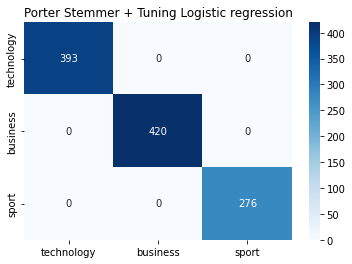

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Porter_tuning_LogReg,
                   op_X_train_PorterStemmer,
                   op_Y_train,
                   'Porter Stemmer + Tuning Logistic regression',
                   'train')

AUC-ROC Score: 100.0000


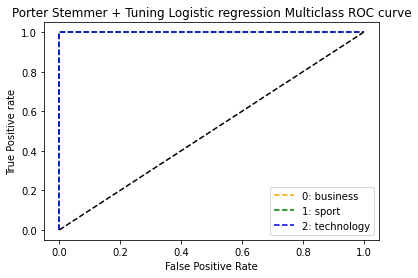

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Porter_tuning_LogReg,
                op_X_train_PorterStemmer,
                op_Y_train,
                'Porter Stemmer + Tuning Logistic regression',
                'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5515 
Recall: 98.5348
F1 Score: 98.5374


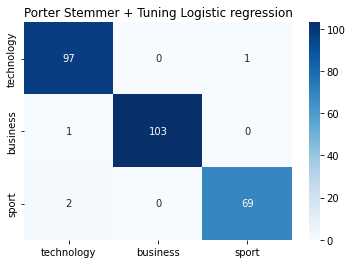

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Porter_tuning_LogReg,
                   op_X_test_PorterStemmer,
                   op_Y_test,
                   'Porter Stemmer + Tuning Logistic regression',
                   'test')

AUC-ROC Score: 99.7724


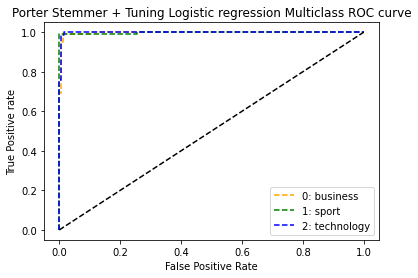

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Porter_tuning_LogReg,
                op_X_test_PorterStemmer,
                op_Y_test,
                'Porter Stemmer + Tuning Logistic regression',
                'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model K-Neighbors Classifier
op_Porter_tuning_KNN = tuning_KNN.fit(op_X_train_PorterStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Porter_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 132 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   46.7s finished
/usr/local/lib/python3.7/dist-packages/sklearn/neighbors/_base.py:414: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: "


{'algorithm': 'ball_tree',
 'leaf_size': 30,
 'metric': 'euclidean',
 'n_jobs': -1,
 'n_neighbors': 7,
 'p': 2,
 'weights': 'distance'}

Train Score

Accuracy Score: 100.0000
Precision: 100.0000 
Recall: 100.0000
F1 Score: 100.0000


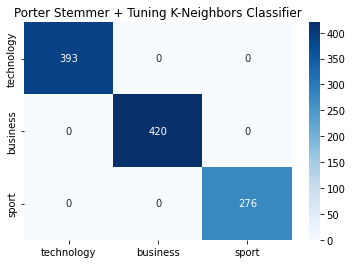

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Porter_tuning_KNN,
                   op_X_train_PorterStemmer,
                   op_Y_train,
                   'Porter Stemmer + Tuning K-Neighbors Classifier',
                   'train')

AUC-ROC Score: 100.0000


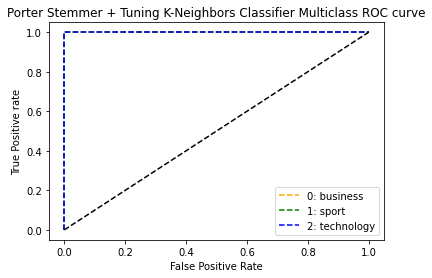

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Porter_tuning_KNN,
                op_X_train_PorterStemmer,
                op_Y_train,
                'Porter Stemmer + Tuning K-Neighbors Classifier',
                'train')

Test Score

Accuracy Score: 95.6044
Precision: 95.6227 
Recall: 95.6044
F1 Score: 95.6115


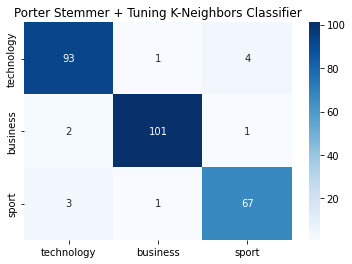

In [ ]:
# แสดง ROC Curve
get_conf_matrix(op_Porter_tuning_KNN,
                   op_X_test_PorterStemmer,
                   op_Y_test,
                   'Porter Stemmer + Tuning K-Neighbors Classifier',
                   'test')

AUC-ROC Score: 98.9444


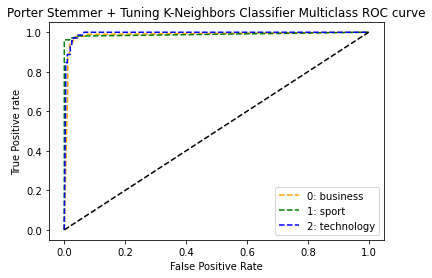

In [ ]:
# แสดง confusion matrix
get_ROC_curv(op_Porter_tuning_KNN,
                op_X_test_PorterStemmer,
                op_Y_test,
                'Porter Stemmer + Tuning K-Neighbors Classifier',
                'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model Multinomial Naive Bayes
op_Porter_tuning_MultiNB = tuning_MultiNB.fit(op_X_train_PorterStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Porter_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.4s finished


{'alpha': 0.5, 'fit_prior': True}

Train Score

Accuracy Score: 99.0817
Precision: 99.0832 
Recall: 99.0817
F1 Score: 99.0812


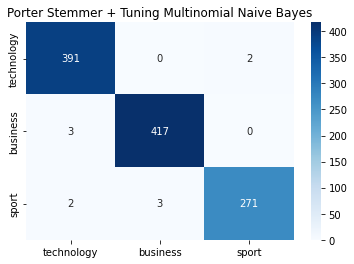

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Porter_tuning_MultiNB,
                   op_X_train_PorterStemmer,
                   op_Y_train,
                   'Porter Stemmer + Tuning Multinomial Naive Bayes',
                   'train')

AUC-ROC Score: 99.9365


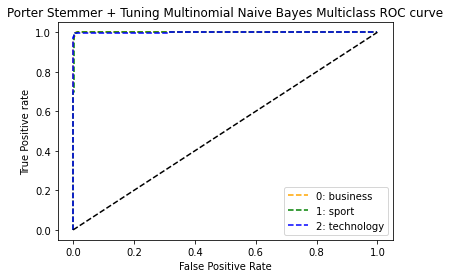

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Porter_tuning_MultiNB,
                op_X_train_PorterStemmer,
                op_Y_train,
                'Porter Stemmer + Tuning Multinomial Naive Bayes',
                'train')

Test Score

Accuracy Score: 97.0696
Precision: 97.1509 
Recall: 97.0696
F1 Score: 97.0670


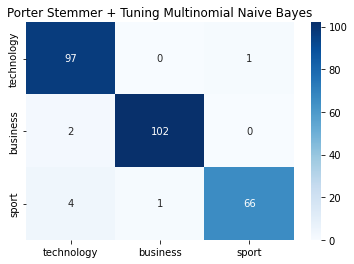

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Porter_tuning_MultiNB,
                   op_X_test_PorterStemmer,
                   op_Y_test,
                   'Porter Stemmer + Tuning Multinomial Naive Bayes',
                   'test')

AUC-ROC Score: 99.7606


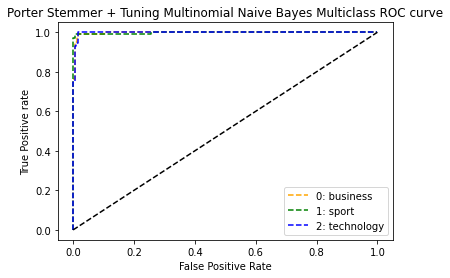

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Porter_tuning_MultiNB,
                op_X_test_PorterStemmer,
                op_Y_test,
                'Porter Stemmer + Tuning Multinomial Naive Bayes',
                'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Porter Stemmer เข้าไป fit กับ model Linear Support Vector Classification
op_Porter_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(op_X_train_PorterStemmer, op_Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 166 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   10.3s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   21.5s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   25.9s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 166 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   13.8s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   25.9s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   23.8s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   24.8s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


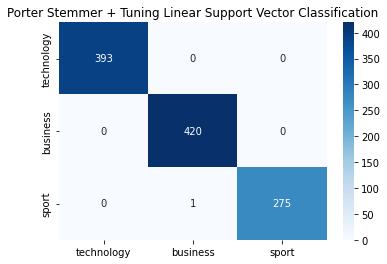

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Porter_tuning_LinSVC,
                   op_X_train_PorterStemmer,
                   op_Y_train,
                   'Porter Stemmer + Tuning Linear Support Vector Classification',
                   'train')

AUC-ROC Score: 99.9987


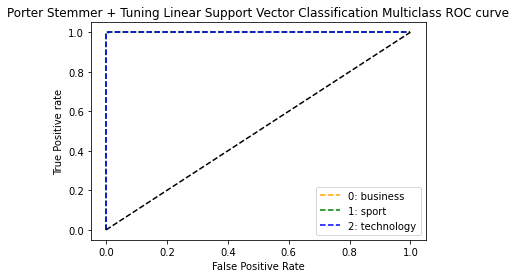

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Porter_tuning_LinSVC,
                op_X_train_PorterStemmer,
                op_Y_train,
                'Porter Stemmer + Tuning Linear Support Vector Classification',
                'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


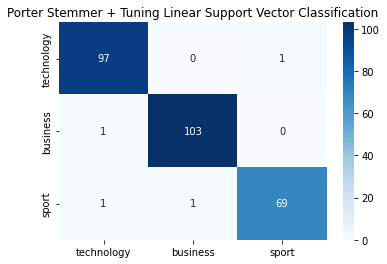

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Porter_tuning_LinSVC,
                   op_X_test_PorterStemmer,
                   op_Y_test,
                   'Porter Stemmer + Tuning Linear Support Vector Classification',
                   'test')

AUC-ROC Score: 99.7370


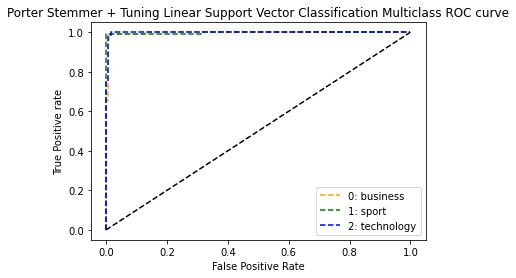

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Porter_tuning_LinSVC,
                op_X_test_PorterStemmer,
                op_Y_test,
                'Porter Stemmer + Tuning Linear Support Vector Classification',
                'test')

### 3: ใช้ Model ทำ Text Classification กับ Text ที่ normalize ด้วย Snowball Stemmer

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model Logistic regression
op_Snowball_tuning_LogReg = tuning_LogReg.fit(op_X_train_SnowballStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Snowball_tuning_LogReg.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    6.5s finished


{'C': 21.544346900318832, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


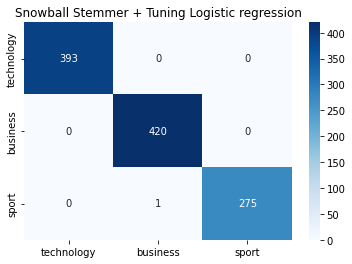

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_LogReg,
                   op_X_train_SnowballStemmer,
                   op_Y_train,
                   'Snowball Stemmer + Tuning Logistic regression',
                   'train')

AUC-ROC Score: 100.0000


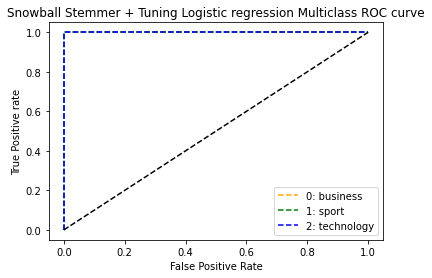

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_LogReg,
                op_X_train_SnowballStemmer,
                op_Y_train,
                'Snowball Stemmer + Tuning Logistic regression',
                'train')

Test Score

Accuracy Score: 98.1685
Precision: 98.1799 
Recall: 98.1685
F1 Score: 98.1654


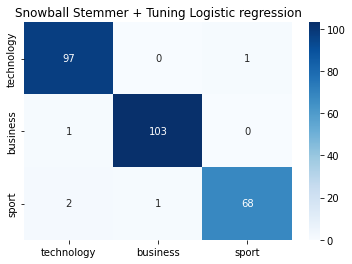

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_LogReg,
                   op_X_test_SnowballStemmer,
                   op_Y_test,
                   'Snowball Stemmer + Tuning Logistic regression',
                   'test')

AUC-ROC Score: 99.7624


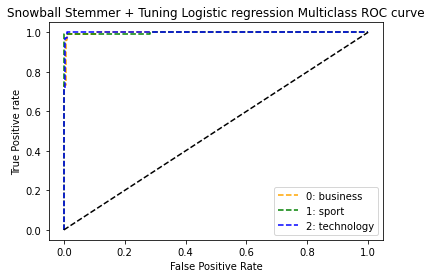

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_LogReg,
                op_X_test_SnowballStemmer,
                op_Y_test,
                'Snowball Stemmer + Tuning Logistic regression',
                'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model K-Neighbors Classifier
op_Snowball_tuning_KNN = tuning_KNN.fit(op_X_train_SnowballStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Snowball_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 134 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   44.9s finished
/usr/local/lib/python3.7/dist-packages/sklearn/neighbors/_base.py:414: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: "


{'algorithm': 'ball_tree',
 'leaf_size': 30,
 'metric': 'euclidean',
 'n_jobs': -1,
 'n_neighbors': 7,
 'p': 2,
 'weights': 'distance'}

Train Score

Accuracy Score: 100.0000
Precision: 100.0000 
Recall: 100.0000
F1 Score: 100.0000


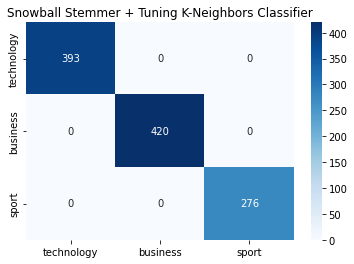

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_KNN,
                   op_X_train_SnowballStemmer,
                   op_Y_train,
                   'Snowball Stemmer + Tuning K-Neighbors Classifier',
                   'train')

AUC-ROC Score: 100.0000


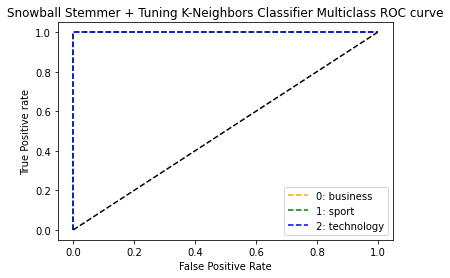

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_KNN,
                op_X_train_SnowballStemmer,
                op_Y_train,
                'Snowball Stemmer + Tuning K-Neighbors Classifier',
                'train')

Test Score

Accuracy Score: 95.6044
Precision: 95.6227 
Recall: 95.6044
F1 Score: 95.6115


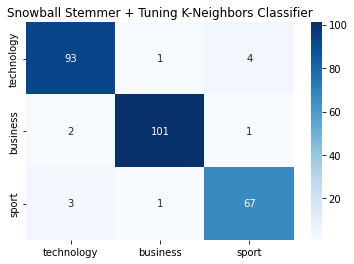

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_KNN,
                   op_X_test_SnowballStemmer,
                   op_Y_test,
                   'Snowball Stemmer + Tuning K-Neighbors Classifier',
                   'test')

AUC-ROC Score: 98.9552


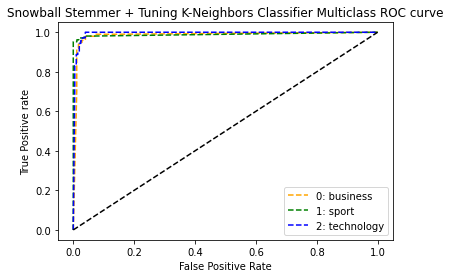

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_KNN,
                op_X_test_SnowballStemmer,
                op_Y_test,
                'Snowball Stemmer + Tuning K-Neighbors Classifier',
                'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model Multinomial Naive Bayes
op_Snowball_tuning_MultiNB = tuning_MultiNB.fit(op_X_train_SnowballStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Snowball_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.4s finished


{'alpha': 0.5, 'fit_prior': True}

Train Score

Accuracy Score: 99.0817
Precision: 99.0832 
Recall: 99.0817
F1 Score: 99.0812


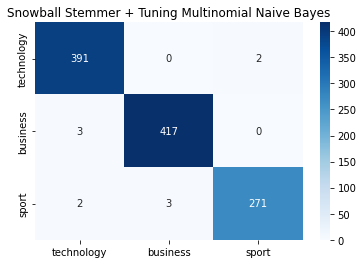

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_MultiNB,
                   op_X_train_SnowballStemmer,
                   op_Y_train,
                   'Snowball Stemmer + Tuning Multinomial Naive Bayes',
                   'train')

AUC-ROC Score: 99.9328


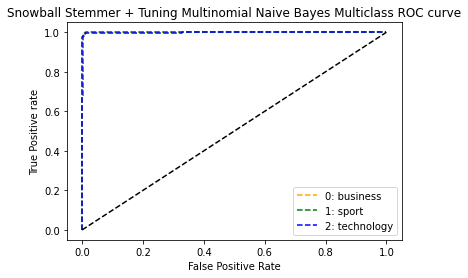

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_MultiNB,
                op_X_train_SnowballStemmer,
                op_Y_train,
                'Snowball Stemmer + Tuning Multinomial Naive Bayes',
                'train')

Test Score

Accuracy Score: 97.4359
Precision: 97.4859 
Recall: 97.4359
F1 Score: 97.4260


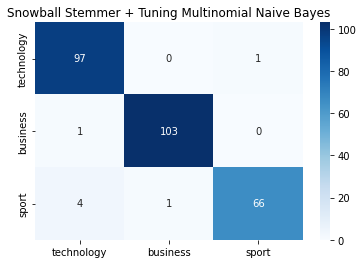

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_MultiNB,
                   op_X_test_SnowballStemmer,
                   op_Y_test,
                   'Snowball Stemmer + Tuning Multinomial Naive Bayes',
                   'test')

AUC-ROC Score: 99.7526


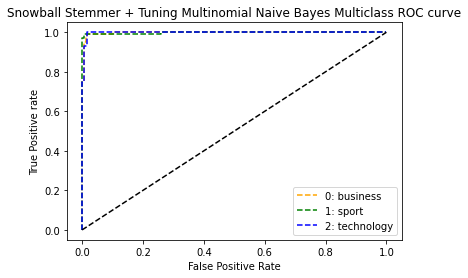

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_MultiNB,
                op_X_test_SnowballStemmer,
                op_Y_test,
                'Snowball Stemmer + Tuning Multinomial Naive Bayes',
                'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Snowball Stemmer เข้าไป fit กับ model Linear Support Vector Classification
op_Snowball_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(op_X_train_SnowballStemmer, op_Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    9.0s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   22.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   26.3s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   11.6s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   25.4s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   23.1s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   25.5s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


Train Score

Accuracy Score: 99.8163
Precision: 99.8166 
Recall: 99.8163
F1 Score: 99.8163


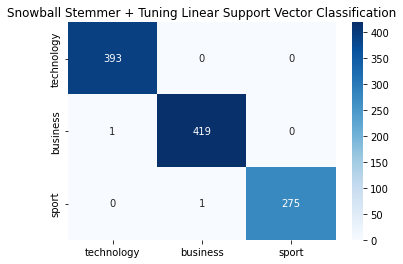

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_LinSVC,
                   op_X_train_SnowballStemmer,
                   op_Y_train,
                   'Snowball Stemmer + Tuning Linear Support Vector Classification',
                   'train')

AUC-ROC Score: 99.9966


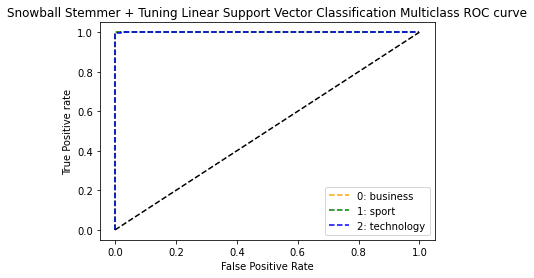

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_LinSVC,
                op_X_train_SnowballStemmer,
                op_Y_train,
                'Snowball Stemmer + Tuning Linear Support Vector Classification',
                'train')

Test Score

Accuracy Score: 98.9011
Precision: 98.9085 
Recall: 98.9011
F1 Score: 98.9030


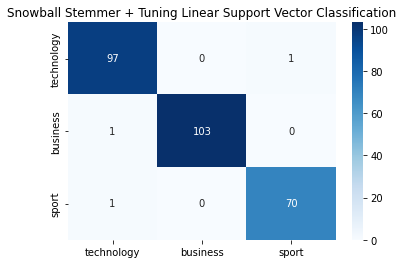

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Snowball_tuning_LinSVC,
                   op_X_test_SnowballStemmer,
                   op_Y_test,
                   'Snowball Stemmer + Tuning Linear Support Vector Classification',
                   'test')

AUC-ROC Score: 99.7322


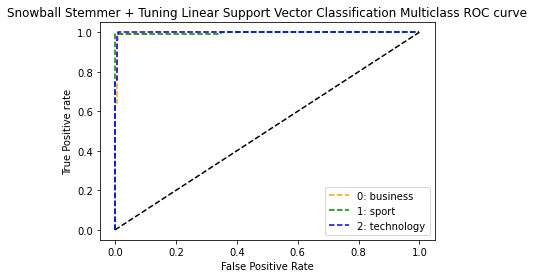

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Snowball_tuning_LinSVC,
                op_X_test_SnowballStemmer,
                op_Y_test,
                'Snowball Stemmer + Tuning Linear Support Vector Classification',
                'test')

### 4: ใช้ Model ทำ Text Classification กับ Text ที่ normalize ด้วย Lancaster Stemmer

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model Logistic regression
op_Lancaster_tuning_LogReg = tuning_LogReg.fit(op_X_train_LancasterStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Lancaster_tuning_LogReg.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    7.3s finished


{'C': 7.742636826811269, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


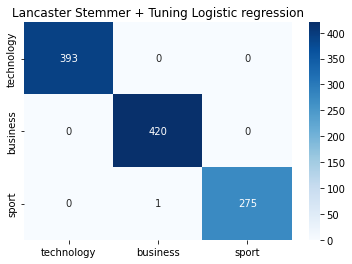

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_LogReg,
                   op_X_train_LancasterStemmer,
                   op_Y_train,
                   'Lancaster Stemmer + Tuning Logistic regression',
                   'train')

AUC-ROC Score: 99.9997


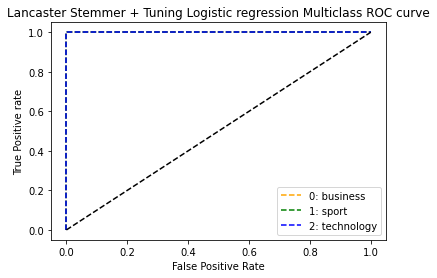

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_LogReg,
                op_X_train_LancasterStemmer,
                op_Y_train,
                'Lancaster Stemmer + Tuning Logistic regression',
                'train')

Test Score

Accuracy Score: 97.8022
Precision: 97.8097 
Recall: 97.8022
F1 Score: 97.7990


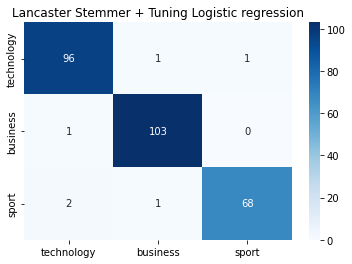

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_LogReg,
                   op_X_test_LancasterStemmer,
                   op_Y_test,
                   'Lancaster Stemmer + Tuning Logistic regression',
                   'test')

AUC-ROC Score: 99.7962


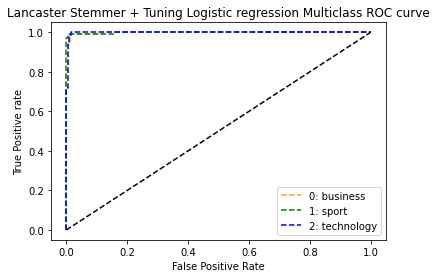

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_LogReg,
                op_X_test_LancasterStemmer,
                op_Y_test,
                'Lancaster Stemmer + Tuning Logistic regression',
                'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model K-Neighbors Classifier
op_Lancaster_tuning_KNN = tuning_KNN.fit(op_X_train_LancasterStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Lancaster_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 132 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   48.7s finished
/usr/local/lib/python3.7/dist-packages/sklearn/neighbors/_base.py:414: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: "


{'algorithm': 'kd_tree',
 'leaf_size': 60,
 'metric': 'minkowski',
 'n_jobs': -1,
 'n_neighbors': 17,
 'p': 2,
 'weights': 'distance'}

Train Score

Accuracy Score: 100.0000
Precision: 100.0000 
Recall: 100.0000
F1 Score: 100.0000


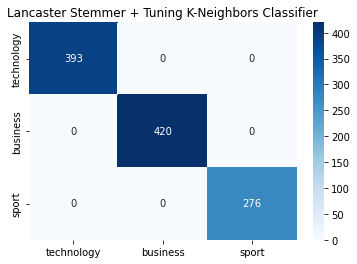

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_KNN,
                   op_X_train_LancasterStemmer,
                   op_Y_train,
                   'Lancaster Stemmer + Tuning K-Neighbors Classifier',
                   'train')

AUC-ROC Score: 100.0000


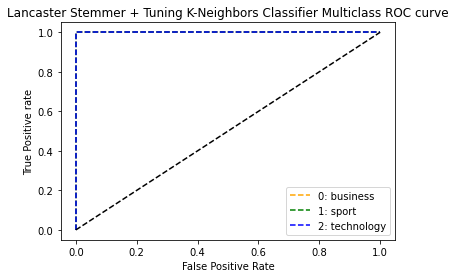

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_KNN,
                op_X_train_LancasterStemmer,
                op_Y_train,
                'Lancaster Stemmer + Tuning K-Neighbors Classifier',
                'train')

Test Score

Accuracy Score: 96.7033
Precision: 96.7280 
Recall: 96.7033
F1 Score: 96.6966


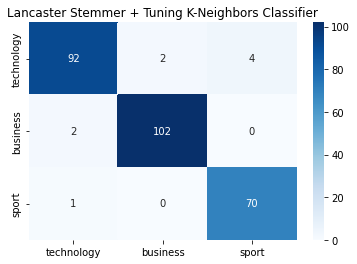

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_KNN,
                   op_X_test_LancasterStemmer,
                   op_Y_test,
                   'Lancaster Stemmer + Tuning K-Neighbors Classifier',
                   'test')

AUC-ROC Score: 99.1611


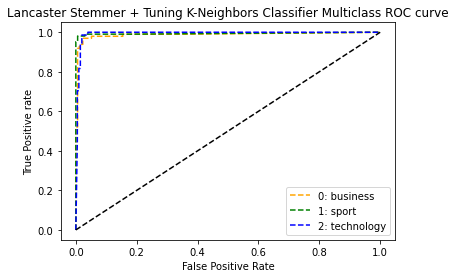

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_KNN,
                op_X_test_LancasterStemmer,
                op_Y_test,
                'Lancaster Stemmer + Tuning K-Neighbors Classifier',
                'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model Multinomial Naive Bayes
op_Lancaster_tuning_MultiNB = tuning_MultiNB.fit(op_X_train_LancasterStemmer, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_Lancaster_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.5s finished


{'alpha': 0.5, 'fit_prior': False}

Train Score

Accuracy Score: 99.0817
Precision: 99.0826 
Recall: 99.0817
F1 Score: 99.0820


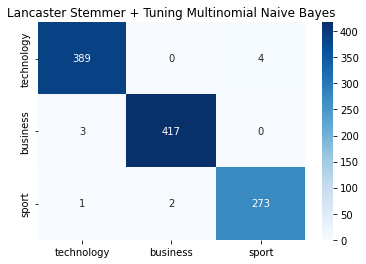

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_MultiNB,
                   op_X_train_LancasterStemmer,
                   op_Y_train,
                   'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
                   'train')

AUC-ROC Score: 99.9385


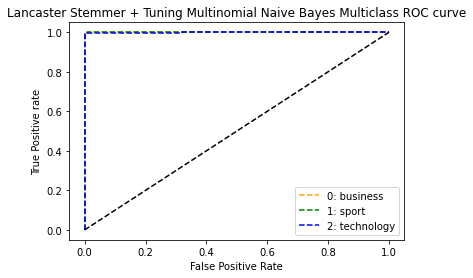

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_MultiNB,
                op_X_train_LancasterStemmer,
                op_Y_train,
                'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
                'train')

Test Score

Accuracy Score: 95.9707
Precision: 95.9918 
Recall: 95.9707
F1 Score: 95.9757


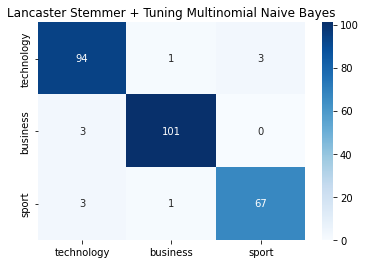

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_MultiNB,
                   op_X_test_LancasterStemmer,
                   op_Y_test,
                   'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
                   'test')

AUC-ROC Score: 99.7807


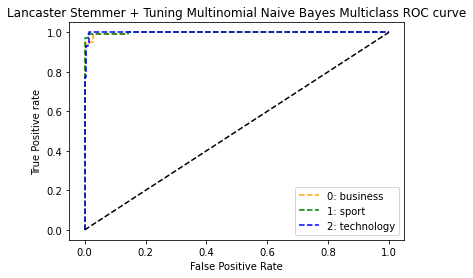

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_MultiNB,
                op_X_test_LancasterStemmer,
                op_Y_test,
                'Lancaster Stemmer + Tuning Multinomial Naive Bayes',
                'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lancaster Stemmer เข้าไป fit กับ model Linear Support Vector Classification
op_Lancaster_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(op_X_train_LancasterStemmer, op_Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 166 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    9.0s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   22.1s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 166 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   17.5s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   23.3s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 166 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   24.1s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


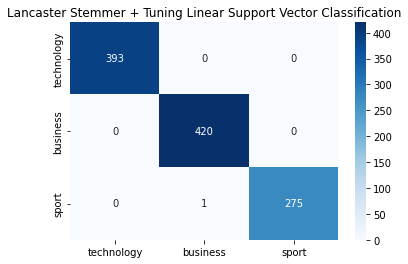

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_LinSVC,
                   op_X_train_LancasterStemmer,
                   op_Y_train,
                   'Lancaster Stemmer + Tuning Linear Support Vector Classification',
                   'train')

AUC-ROC Score: 99.9994


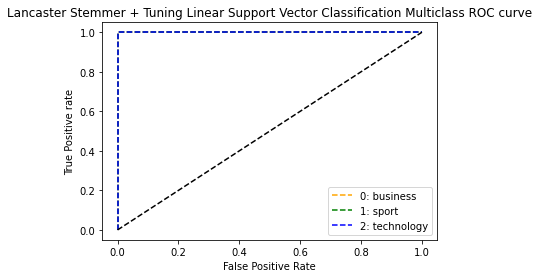

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_LinSVC,
                op_X_train_LancasterStemmer,
                op_Y_train,
                'Lancaster Stemmer + Tuning Linear Support Vector Classification',
                'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


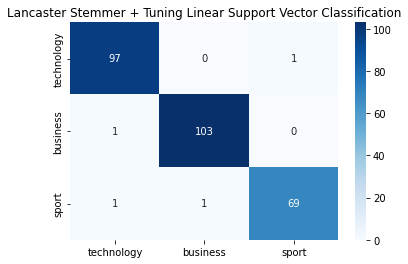

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_Lancaster_tuning_LinSVC,
                   op_X_test_LancasterStemmer,
                   op_Y_test,
                   'Lancaster Stemmer + Tuning Linear Support Vector Classification',
                   'test')

AUC-ROC Score: 99.7974


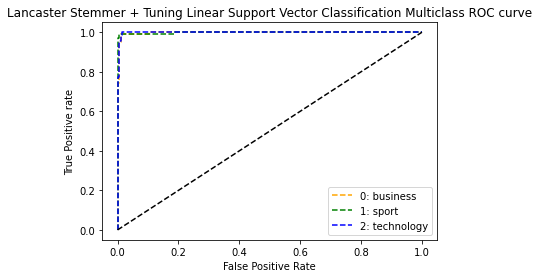

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_Lancaster_tuning_LinSVC,
                op_X_test_LancasterStemmer,
                op_Y_test,
                'Lancaster Stemmer + Tuning Linear Support Vector Classification',
                'test')

### 5: ใช้ Model ทำ Text Classification กับ Text ที่ normalize ด้วย Lemmatizer with POS

**Logistic regression**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model Logistic regression
op_lemma_w_pos_tuning_LogReg = tuning_LogReg.fit(op_X_train_Lemma_w_POS_Tag, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_lemma_w_pos_tuning_LogReg.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    6.5s finished


{'C': 59.94842503189409, 'penalty': 'l2', 'solver': 'liblinear'}

Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


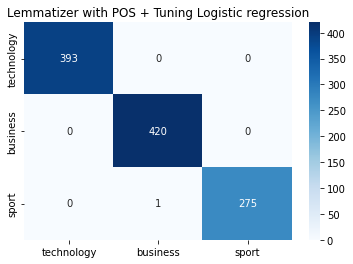

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_LogReg,
                   op_X_train_Lemma_w_POS_Tag,
                   op_Y_train,
                   'Lemmatizer with POS + Tuning Logistic regression',
                   'train')

AUC-ROC Score: 100.0000


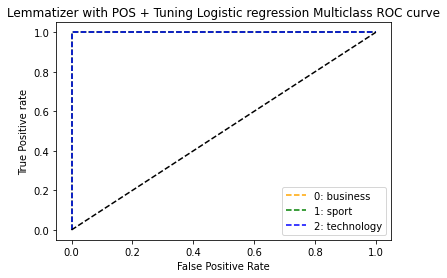

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_LogReg,
                op_X_train_Lemma_w_POS_Tag,
                op_Y_train,
                'Lemmatizer with POS + Tuning Logistic regression',
                'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


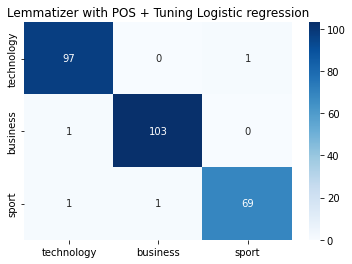

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_LogReg,
                   op_X_test_Lemma_w_POS_Tag,
                   op_Y_test,
                   'Lemmatizer with POS + Tuning Logistic regression',
                   'test')

AUC-ROC Score: 99.6900


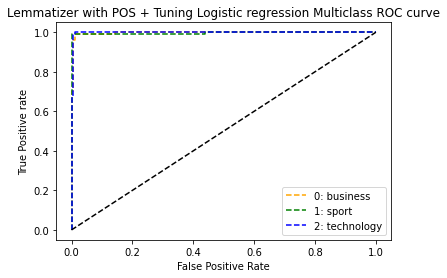

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_LogReg,
                op_X_test_Lemma_w_POS_Tag,
                op_Y_test,
                'Lemmatizer with POS + Tuning Logistic regression',
                'test')

**K-Neighbors Classifier**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model K-Neighbors Classifier
op_lemma_w_pos_tuning_KNN = tuning_KNN.fit(op_X_train_Lemma_w_POS_Tag, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_lemma_w_pos_tuning_KNN.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 134 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   43.5s finished


{'algorithm': 'brute',
 'leaf_size': 60,
 'metric': 'minkowski',
 'n_jobs': -1,
 'n_neighbors': 11,
 'p': 2,
 'weights': 'distance'}

Train Score

Accuracy Score: 100.0000
Precision: 100.0000 
Recall: 100.0000
F1 Score: 100.0000


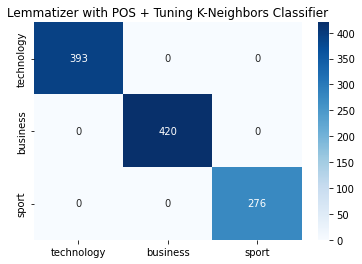

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_KNN,
                   op_X_train_Lemma_w_POS_Tag,
                   op_Y_train,
                   'Lemmatizer with POS + Tuning K-Neighbors Classifier',
                   'train')

AUC-ROC Score: 100.0000


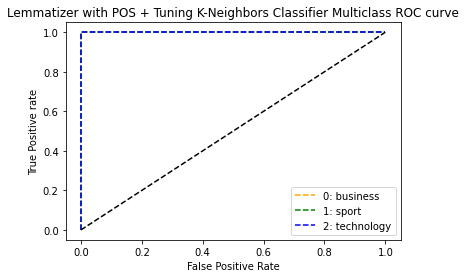

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_KNN,
                op_X_train_Lemma_w_POS_Tag,
                op_Y_train,
                'Lemmatizer with POS + Tuning K-Neighbors Classifier',
                'train')

Test Score

Accuracy Score: 94.8718
Precision: 94.8596 
Recall: 94.8718
F1 Score: 94.8636


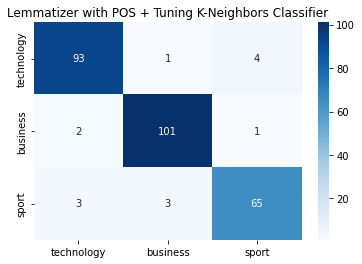

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_KNN,
                   op_X_test_Lemma_w_POS_Tag,
                   op_Y_test,
                   'Lemmatizer with POS + Tuning K-Neighbors Classifier',
                   'test')

AUC-ROC Score: 99.2115


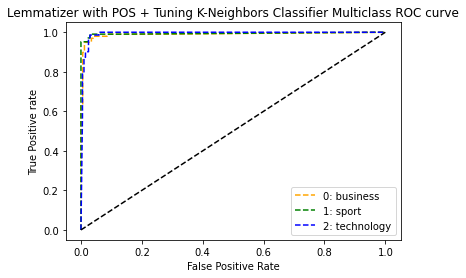

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_KNN,
                op_X_test_Lemma_w_POS_Tag,
                op_Y_test,
                'Lemmatizer with POS + Tuning K-Neighbors Classifier',
                'test')

**Multinomial Naive Bayes**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model Multinomial Naive Bayes
op_lemma_w_pos_tuning_MultiNB = tuning_MultiNB.fit(op_X_train_Lemma_w_POS_Tag, op_Y_train)

# ทำการดู parameter ที่ได้จากการ tune model
op_lemma_w_pos_tuning_MultiNB.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.4s finished


{'alpha': 0.5, 'fit_prior': True}

Train Score

Accuracy Score: 99.0817
Precision: 99.0817 
Recall: 99.0817
F1 Score: 99.0816


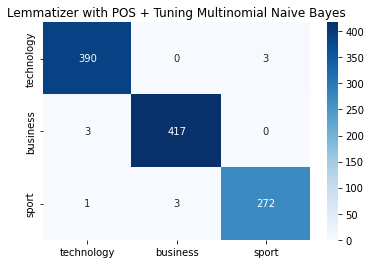

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_MultiNB,
                   op_X_train_Lemma_w_POS_Tag,
                   op_Y_train,
                   'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
                   'train')

AUC-ROC Score: 99.9358


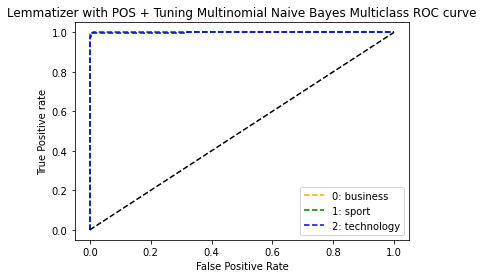

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_MultiNB,
                op_X_train_Lemma_w_POS_Tag,
                op_Y_train,
                'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
                'train')

Test Score

Accuracy Score: 97.0696
Precision: 97.0917 
Recall: 97.0696
F1 Score: 97.0613


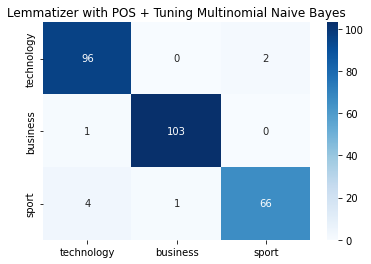

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_MultiNB,
                   op_X_test_Lemma_w_POS_Tag,
                   op_Y_test,
                   'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
                   'test')

AUC-ROC Score: 99.7334


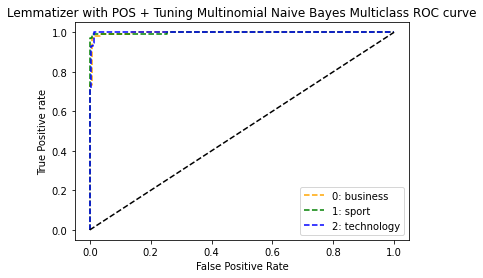

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_MultiNB,
                op_X_test_Lemma_w_POS_Tag,
                op_Y_test,
                'Lemmatizer with POS + Tuning Multinomial Naive Bayes',
                'test')

**Linear Support Vector Classification**

In [ ]:
# นำเอา Text ที่ normalize ด้วย Lemmatizer with POS เข้าไป fit กับ model Linear Support Vector Classification
op_lemma_w_pos_tuning_LinSVC = CalibratedClassifierCV(tuning_LinSVC).fit(op_X_train_Lemma_w_POS_Tag, op_Y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 195 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   10.0s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   17.4s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   12.5s finished
/usr/local/lib/python3.7/dist-packages/sklearn/svm/_base.py:947: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   17.8s finished
/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:281: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:   19.0s finished


Train Score

Accuracy Score: 99.9082
Precision: 99.9084 
Recall: 99.9082
F1 Score: 99.9081


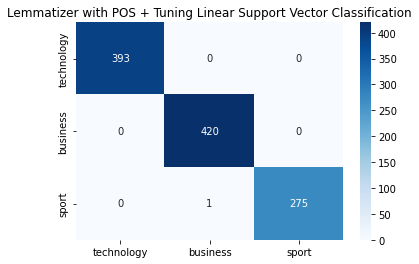

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_LinSVC,
                   op_X_train_Lemma_w_POS_Tag,
                   op_Y_train,
                   'Lemmatizer with POS + Tuning Linear Support Vector Classification',
                   'train')

AUC-ROC Score: 99.9978


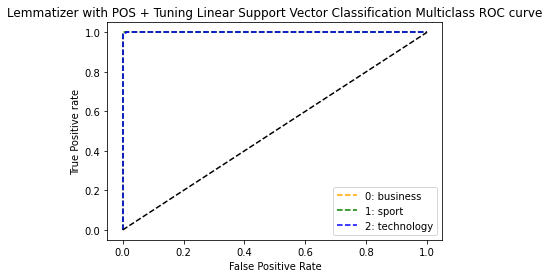

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_LinSVC,
                op_X_train_Lemma_w_POS_Tag,
                op_Y_train,
                'Lemmatizer with POS + Tuning Linear Support Vector Classification',
                'train')

Test Score

Accuracy Score: 98.5348
Precision: 98.5370 
Recall: 98.5348
F1 Score: 98.5337


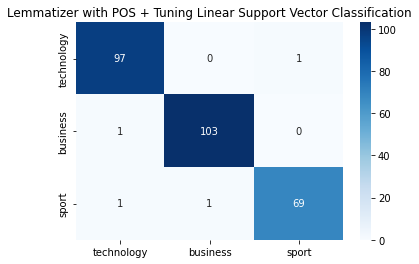

In [ ]:
# แสดง confusion matrix
get_conf_matrix(op_lemma_w_pos_tuning_LinSVC,
                   op_X_test_Lemma_w_POS_Tag,
                   op_Y_test,
                   'Lemmatizer with POS + Tuning Linear Support Vector Classification',
                   'test')

AUC-ROC Score: 99.6649


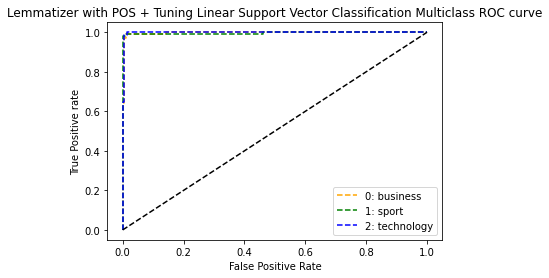

In [ ]:
# แสดง ROC Curve
get_ROC_curv(op_lemma_w_pos_tuning_LinSVC,
                op_X_test_Lemma_w_POS_Tag,
                op_Y_test,
                'Lemmatizer with POS + Tuning Linear Support Vector Classification',
                'test')

### 6: All Tuning Model Score

นำเอา score ที่ได้จาก model ต่างๆ มาทำเป็น dataframe เพื่อเปรียบเทียบ score ของแต่ละ model

In [ ]:
# เอา Score ที่เก็บไว้มาสร้าง dataframe เพื่อแสดงประสิทธิภาพของแต่ละ Model
op_Score_df = pd.DataFrame(all_op_score)
op_Score_df

,Model_Name,Train_Accuracy_Score,Test_Accuracy_Score,Train_ROC_AUC_Score,Test_ROC_AUC_Score,Train_Precision_Score,Test_Precision_Score,Train_Recall_Score,Test_Recall_Score,Train_F1_Score,Test_F1_Score
0,Porter Stemmer + Tuning Logistic regression,100.000000,98.534799,100.000000,99.772357,100.000000,98.551544,100.000000,98.534799,100.000000,98.537417
1,Porter Stemmer + Tuning K-Neighbors Classifier,100.000000,95.604396,100.000000,98.944394,100.000000,95.622721,100.000000,95.604396,100.000000,95.611499
2,Porter Stemmer + Tuning Multinomial Naive Bayes,99.081726,97.069597,99.936544,99.760650,99.083186,97.150862,99.081726,97.069597,99.081192,97.066982
3,Porter Stemmer + Tuning Linear Support Vector ...,99.908173,98.534799,99.998744,99.737039,99.908391,98.536966,99.908173,98.534799,99.908144,98.533691
4,Snowball Stemmer + Tuning Logistic regression,99.908173,98.168498,100.000000,99.762394,99.908391,98.179859,99.908173,98.168498,99.908144,98.165432
5,Snowball Stemmer + Tuning K-Neighbors Classifier,100.000000,95.604396,100.000000,98.955230,100.000000,95.622721,100.000000,95.604396,100.000000,95.611499
6,Snowball Stemmer + Tuning Multinomial Naive Bayes,99.081726,97.435897,99.932814,99.752571,99.083186,97.485852,99.081726,97.435897,99.081192,97.426023
7,Snowball Stemmer + Tuning Linear Support Vecto...,99.816345,98.901099,99.996643,99.732165,99.816578,98.908499,99.816345,98.901099,99.816320,98.903003
8,Lancaster Stemmer + Tuning Logistic regression,99.908173,97.802198,99.999724,99.796216,99.908391,97.809658,99.908173,97.802198,99.908144,97.799010
9,Lancaster Stemmer + Tuning K-Neighbors Classifier,100.000000,96.703297,100.000000,99.161142,100.000000,96.727995,100.000000,96.703297,100.000000,96.696621


 สรุป

1.   ผลลัพธ์จากการทำ Text Classification กับข้อมูล Heading + Content พบว่า model ที่มีค่า Accuracy Score  จากชุดข้อมูล Test มากกว่า 97.5 % ยังคงเป็น Logistic regression และ Linear Support Vector Classification ซึ่งอาจทำให้สรุปได้ว่า Logistic regression และ Linear Support Vector Classification มีความเหมาะสมในการทำ Text Classification กับข้อมูล Heading + Content มากกว่า K-Neighbors Classifier และ Multinomial Naive Bayes ด้วยเช่นกันกับข้อมูล Content
2.   ผลลัพธ์จากกการทำ Text Normalization กับข้อมูล Heading + Content ด้วย Snowball Stemmer และ Lemmatizer with POS เมื่อใช้ร่วมกันกับ Model Logistic regression และ Linear Support Vector Classification แล้วค่า Accuracy Score ส่วนใหญ่ที่ได้ของข้อมูลชุด Test จะยังคงอยู่ที่ 98.534799 % แต่ก็ยังไม่ถือว่าเป็นค่า Accuracy Score ที่สูงที่สุดของข้อมูลชุด test เหมือนในข้อมูล Content โดยค่า Accuracy Score ที่สูงที่สุดได้มาจาก Snowball Stemmer + Tuning Linear Support Vector Classification ซึ่งมีค่า Accuracy Score ที่สูงที่สุดของข้อมูลชุด test อยู่ที่ 98.901099 % แต่ยังมีสิ่งที่น่าสนใจอีกอย่างในการทำ Text Classification ครั้งนี้คือ Accuracy Score ของข้อมูลชุด Train ที่สามารถมีค่าได้ถึง 100% ใน model K-Neighbors Classifier ซึ่งไม่เคยเกิดกับข้อมูล Content

## Task 7: Conclusion

ทำการสรุปผลลัพธ์ที่ได้จากทำ Text Classification ในรูปแบบต่างๆ

**1: Text Classification with Tuning Model (Content)**

In [ ]:
# นำเอา dataframe ข้อมูล score มา plot เปรียบเทียบและดูคะแนน
Con_Score_df = Score_df[['Model_Name', 'Train_Accuracy_Score', 'Test_Accuracy_Score']].copy()
Con_Score_df

,Model_Name,Train_Accuracy_Score,Test_Accuracy_Score
0,Porter Stemmer + Tuning Logistic regression,99.908173,98.168498
1,Porter Stemmer + Tuning K-Neighbors Classifier,99.908173,96.336996
2,Porter Stemmer + Tuning Multinomial Naive Bayes,99.173554,97.435897
3,Porter Stemmer + Tuning Linear Support Vector ...,99.908173,98.534799
4,Snowball Stemmer + Tuning Logistic regression,99.908173,98.534799
5,Snowball Stemmer + Tuning K-Neighbors Classifier,97.979798,95.970696
6,Snowball Stemmer + Tuning Multinomial Naive Bayes,98.989899,97.069597
7,Snowball Stemmer + Tuning Linear Support Vecto...,99.816345,98.534799
8,Lancaster Stemmer + Tuning Logistic regression,99.908173,98.168498
9,Lancaster Stemmer + Tuning K-Neighbors Classifier,99.908173,96.336996


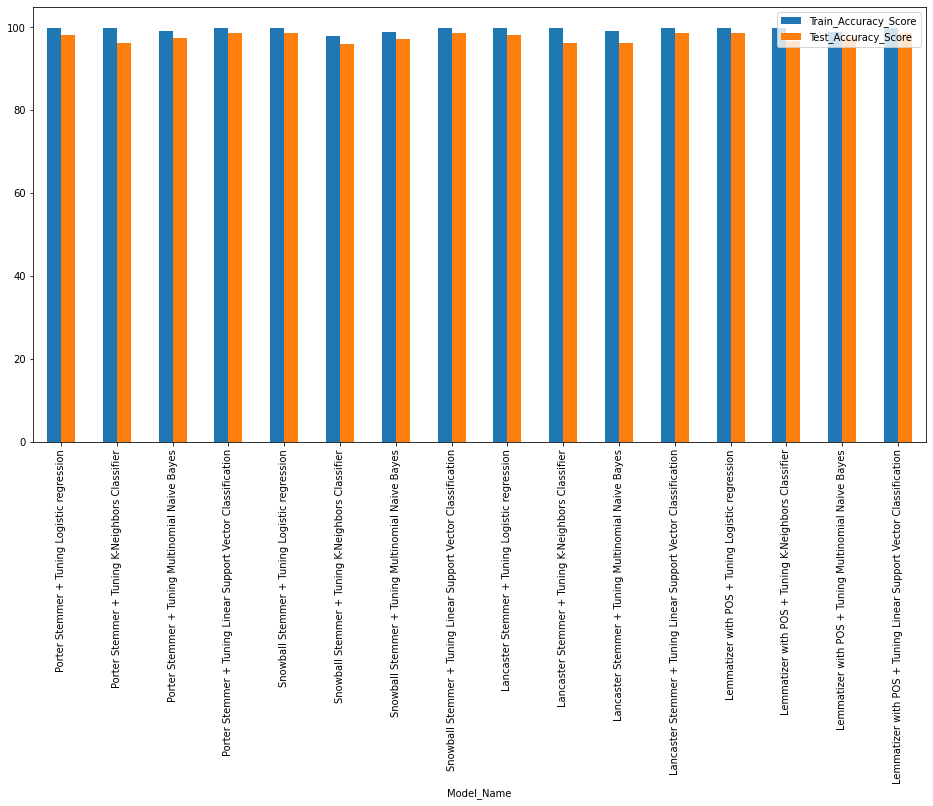

In [ ]:
Con_Score_df.plot(x="Model_Name", y=["Train_Accuracy_Score", "Test_Accuracy_Score"], kind="bar",figsize=(16,8))
plt.show()

**2: Text Classification with Tuning Model and Vectorizer (Content)**

In [ ]:
# นำเอา dataframe ข้อมูล score มา plot เปรียบเทียบและดูคะแนน
Con_tuning_Score_df = tuning_Score_df[['Model_Name', 'Train_Accuracy_Score', 'Test_Accuracy_Score']].copy()
Con_tuning_Score_df

,Model_Name,Train_Accuracy_Score,Test_Accuracy_Score
0,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,99.908173,97.435897
1,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,98.255280,97.435897
2,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,98.438935,96.336996
3,Tuning TfidfVectorizer + Porter Stemmer + Tuni...,99.908173,98.168498


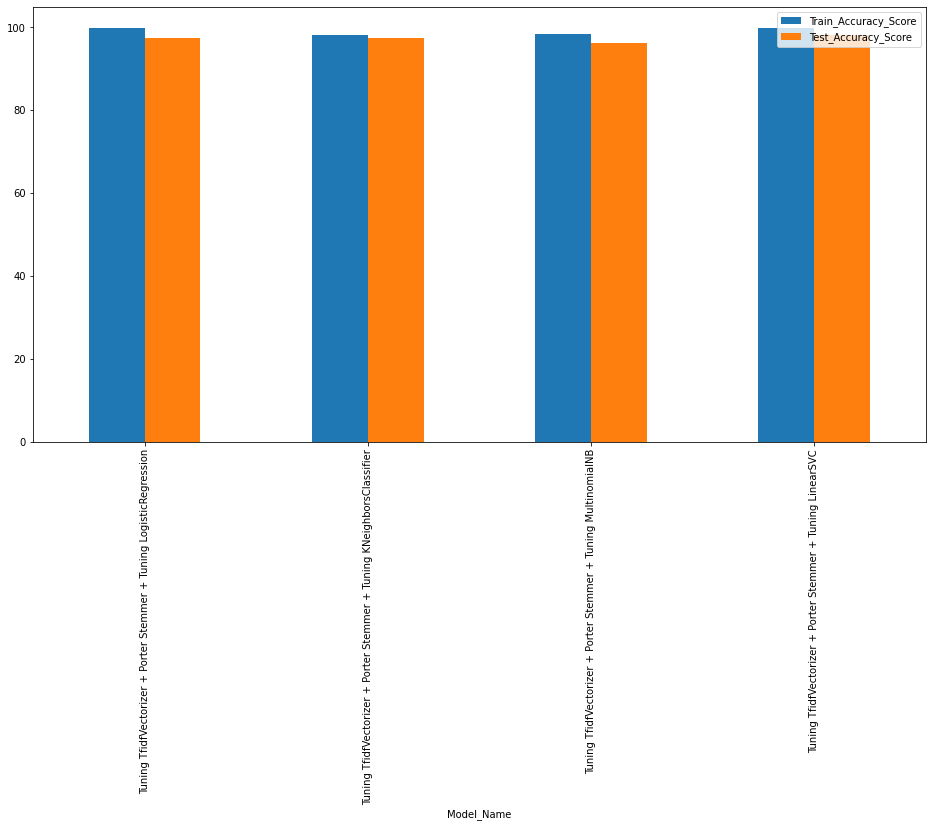

In [ ]:
Con_tuning_Score_df.plot(x="Model_Name", y=["Train_Accuracy_Score", "Test_Accuracy_Score"], kind="bar",figsize=(16,8))
plt.show()

**3: Text Classification with Tuning Model (Heading + Content)**

In [ ]:
# นำเอา dataframe ข้อมูล score มา plot เปรียบเทียบและดูคะแนน
Con_op_Score_df = op_Score_df[['Model_Name', 'Train_Accuracy_Score', 'Test_Accuracy_Score']].copy()
Con_op_Score_df

,Model_Name,Train_Accuracy_Score,Test_Accuracy_Score
0,Porter Stemmer + Tuning Logistic regression,100.000000,98.534799
1,Porter Stemmer + Tuning K-Neighbors Classifier,100.000000,95.604396
2,Porter Stemmer + Tuning Multinomial Naive Bayes,99.081726,97.069597
3,Porter Stemmer + Tuning Linear Support Vector ...,99.908173,98.534799
4,Snowball Stemmer + Tuning Logistic regression,99.908173,98.168498
5,Snowball Stemmer + Tuning K-Neighbors Classifier,100.000000,95.604396
6,Snowball Stemmer + Tuning Multinomial Naive Bayes,99.081726,97.435897
7,Snowball Stemmer + Tuning Linear Support Vecto...,99.816345,98.901099
8,Lancaster Stemmer + Tuning Logistic regression,99.908173,97.802198
9,Lancaster Stemmer + Tuning K-Neighbors Classifier,100.000000,96.703297


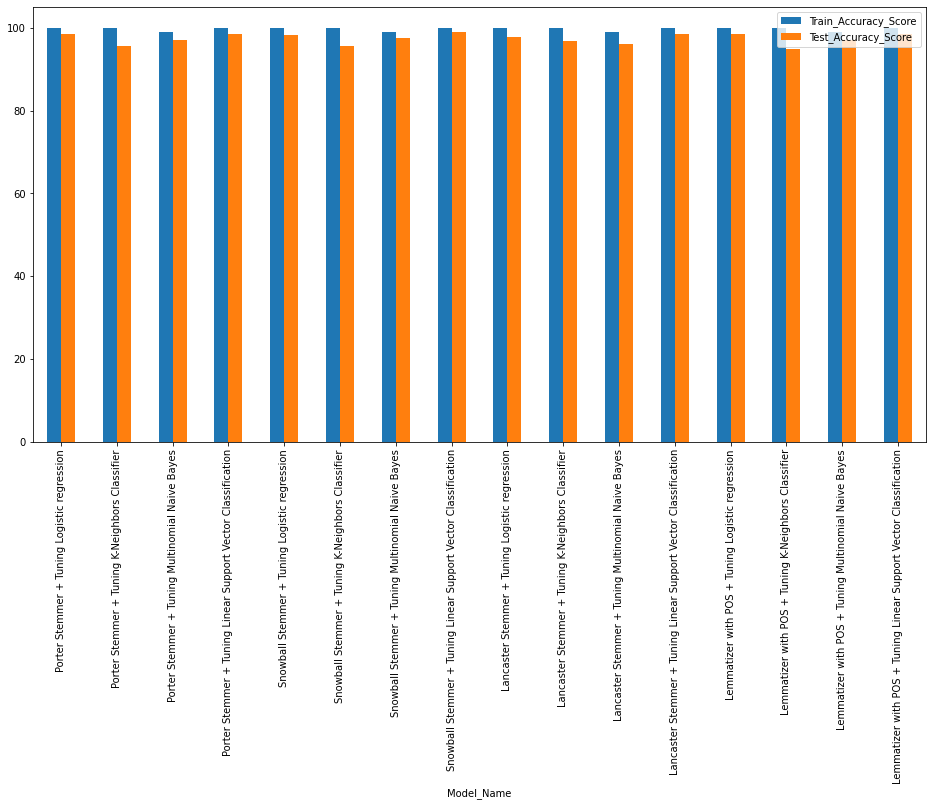

In [ ]:
Con_op_Score_df.plot(x="Model_Name", y=["Train_Accuracy_Score", "Test_Accuracy_Score"], kind="bar",figsize=(16,8))
plt.show()

**4: Conclusion**

สรุปจากการทำพบว่า model ที่มีประสิทธิภาพในการทำ Text Classification กับข้อมูลชุดนี้มากที่สุดคือ Logistic regression และ Linear Support Vector Classificationรูปแบบการทำ Text normalization ที่ทำให้ค่า Accuracy score ได้สูงขึ้นส่วนใหญ่มักจะเป็น Snowball Stemmer และ Lemmatizer with POSผลจากการ tune model และ vectorizer ส่วนใหญ่จะส่งผลให้ค่า Accuracy score เพิ่มขึ้น มีเพียงบาง model เท่านั้นที่ค่า Accuracy Score ลดลง และการทำ Text Classification แบบการ tune model เพียงอย่างเดียวกับข้อมูล Heading + Content ก็ส่งผลให้ค่า Accucary Score เพิ่มขึ้นในบาง model บางโดยส่วนใหญ่จะได้ค่าเท่าเดิมเหมือนตอนที่ทำกับ Content เพียงอย่างเดียวและมีเพียงบาง model เท่านั้นที่ได้ค่า Accuracy score ลดลง